## Summary of the deliverable

### Why we trained the baseline model again
We re-trained the baseline model because our earlier baseline run suffered from **class collapse**, meaning it was predicting almost only one class. After inspecting the pipeline, we found that this was not just a training issue — it was also caused by a **data preprocessing error** that affected how the inputs were being prepared. Since that issue could make the comparison unfair, we trained the baseline again after correcting the preprocessing pipeline.

At the same time, we made **small stability-oriented tweaks** to the baseline architecture and training setup so that it would remain close to the original CrossTransformer-style baseline, but would be less likely to collapse. In particular, the corrected baseline kept the same general architecture family while improving stability through:
- better preprocessing and corrected paired data construction,
- class-imbalance handling,
- more stable training and checkpoint selection,
- and light architectural stabilizations so that one unstable branch would not dominate the prediction.

This gave us a **fairer and stronger baseline** for comparison against our actual model.

---

### Baseline vs Actual Model: Test-set Comparison

| Metric | Baseline (Corrected CrossTransformer-style) | Actual Model (Improved Missing-Modality Fusion V2) |
|---|---:|---:|
| Accuracy | 0.625 | 0.625 |
| Sensitivity (Recall for Positive Class) | 0.000 | 0.500 |
| Specificity | 0.833 | 0.667 |
| Balanced Accuracy | 0.417 | 0.583 |
| F1 Score | 0.000 | 0.400 |
| MCC | -0.218 | 0.149 |
| AUC | 0.667 | 0.500 |

### Comments on the results
Although the **accuracy is the same** for both models, the actual model is still more useful overall for this task. The reason is that accuracy alone can be misleading on a **small and imbalanced test set**.

The baseline model effectively behaved like a majority-class predictor on the test set:
- it had **0 sensitivity**, meaning it failed to correctly detect any positive case,
- it had **F1 = 0**, which shows poor positive-class performance,
- and its **negative MCC** suggests weak or misleading prediction behavior.

By contrast, our actual model:
- detected some positive samples (**sensitivity = 0.500**),
- achieved a better **balanced accuracy**,
- achieved a clearly better **F1 score**,
- and improved **MCC** from negative to positive.

So even though both models have the same raw accuracy, the actual model is **less collapsed**, more balanced, and more meaningful for the positive class.

It is also important to note that this deliverable used a **very small test set**, so the metrics are highly sensitive to even one or two predictions. For example, on a test set of only 8 samples, one extra correct or incorrect prediction changes accuracy by **12.5%**. In the **final deliverable**, we will expand the evaluation and use a broader test setup so that the comparison is more reliable and statistically meaningful.

---

### Architecture of the Actual Model
Below is the diagram of the architecture used for our actual model.

![Actual Model Architecture](actual_model_architecture.png)

### Short explanation of the architecture
Our actual model uses **two separate 3D encoders**, one for MRI and one for PET. Each encoder produces multi-scale features, which are summarized into compact modality-specific embeddings. The model then:
1. keeps **MRI as the anchor modality**,
2. allows **PET to contribute only when it is present**,
3. uses a **modality mask** to handle missing PET safely,
4. builds a **joint summary** from MRI, PET, and modality availability,
5. applies a **gate** so that PET contributes in a controlled way instead of dominating the decision,
6. combines the fused prediction with **auxiliary MRI-only and PET-only heads** to stabilize learning.

This design helps the model avoid collapsing into a single-class solution while still benefiting from multimodal fusion when PET is available.

---

### What we learned from this implementation
From this implementation, we learned several important things:

- **Data preprocessing matters as much as architecture.**  
  A preprocessing error can make the model appear much worse than it really is and can even cause class collapse.

- **Accuracy alone is not enough.**  
  For imbalanced medical tasks, metrics such as sensitivity, balanced accuracy, F1, and MCC are often more informative than plain accuracy.

- **Missing-modality handling must be explicit.**  
  If PET is missing or inconsistently available, the model must be designed to handle that condition directly instead of assuming both modalities are always present.

- **A model that predicts both classes is already an improvement over a collapsed model.**  
  Even when accuracy is unchanged, better sensitivity and F1 indicate a more clinically meaningful direction.

- **Tiny test sets can distort interpretation.**  
  Small-sample evaluation makes every prediction disproportionately important, so conclusions must remain careful and provisional.

---

### How we can improve this further in the final deliverable
For the final deliverable, we plan to extend both the **architecture** and the **target setup** to improve performance further. Some clear next steps are:

- increase the evaluation size and make the train/validation/test setup more robust,
- improve label and tracer consistency so that the target is better aligned with the available imaging,
- extend the fusion mechanism so that MRI–PET interaction is learned more effectively,
- improve imbalance handling further,
- and explore stronger representation learning so that both **accuracy and the other metrics** improve together.

In short, this deliverable shows that we were able to **fix the collapse issue**, build a more stable multimodal system, and obtain a model that is already more balanced than the baseline. In the final deliverable, we will build on this foundation to improve overall predictive performance more substantially.

## First the baseline model

In [1]:

# =======================================
# 1) Imports and baseline-run config
# =======================================
import os
import gc
import math
import random
import warnings
import re
import json
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    recall_score,
    classification_report,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

BASELINE_SEED = 2026
random.seed(BASELINE_SEED)
np.random.seed(BASELINE_SEED)
torch.manual_seed(BASELINE_SEED)
torch.cuda.manual_seed_all(BASELINE_SEED)

def baseline_seed_worker(worker_id):
    worker_seed = BASELINE_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

baseline_g = torch.Generator()
baseline_g.manual_seed(BASELINE_SEED)

BASELINE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("BASELINE_DEVICE:", BASELINE_DEVICE)

# Kaggle dataset discovery
BASELINE_KAGGLE_INPUT_ROOT = Path("/kaggle/input")
BASELINE_LOCAL_FALLBACK_ROOTS = [Path("./"), Path("../input")]

# Task setup
BASELINE_TARGET_COLUMN = "Amyloid_status"
BASELINE_POSITIVE_LABEL = "positive"
BASELINE_NEGATIVE_LABEL = "negative"

# IMPORTANT:
# Do NOT require AV45 here. Requiring AV45 discards most PET in ds006148 and
# effectively collapses the available paired training set.
BASELINE_PREFER_TRACER = "ANY_BEST_AVAILABLE"

# Keep the baseline on paired MRI+PET only, to stay close to the cited baseline setting
BASELINE_ONLY_PAIRED = True
BASELINE_KEEP_ONE_SESSION_PER_SUBJECT = True

# Robust split requirements so val/test do not become degenerate
BASELINE_MIN_TRAIN_POS = 5
BASELINE_MIN_VAL_POS = 2
BASELINE_MIN_TEST_POS = 2
BASELINE_MAX_SPLIT_TRIES = 250

# Compute / training
BASELINE_IMG_SIZE = (96, 96, 96)
BASELINE_BATCH_SIZE = 2
BASELINE_NUM_WORKERS = 0
BASELINE_EPOCHS = 8
BASELINE_LR = 6e-5
BASELINE_GRAD_CLIP_NORM = 3.0
BASELINE_WEIGHT_DECAY = 2e-4
BASELINE_PATIENCE = 5
BASELINE_ACCUM_STEPS = 2

# CrossTransformer-like baseline hyperparameters
BASELINE_TOKEN_DIM = 96
BASELINE_NHEAD = 4
BASELINE_DROPOUT = 0.15

BASELINE_TEST_SIZE = 0.15
BASELINE_VAL_SIZE_WITHIN_TRAINVAL = 0.17647058823529413

BASELINE_SAVE_DIR = Path("./corrected_baseline_run")
BASELINE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

BASELINE_MODEL_PATH = Path("baseline_model.pt")
BASELINE_THRESH_GRID = np.linspace(0.05, 0.95, 37)

print("Baseline model will be saved to:", BASELINE_MODEL_PATH.resolve())


BASELINE_DEVICE: cuda
Baseline model will be saved to: /kaggle/working/baseline_model.pt


In [2]:
# ===========================================
# 2) Discover ds006148 Kaggle dataset roots
# ===========================================
def baseline_find_dataset_roots():
    roots = []
    qnld_files = []
    participants_files = []

    search_roots = []
    if BASELINE_KAGGLE_INPUT_ROOT.exists():
        search_roots.append(BASELINE_KAGGLE_INPUT_ROOT)
    search_roots.extend([p for p in BASELINE_LOCAL_FALLBACK_ROOTS if p.exists()])

    seen = set()

    for root in search_roots:
        for p in root.rglob("ds006148_data"):
            if p.is_dir():
                rp = str(p.resolve())
                if rp not in seen:
                    roots.append(p)
                    seen.add(rp)

        for p in root.rglob("QNLD_cognitive_scores*"):
            if p.is_file():
                qnld_files.append(p)

        for p in root.rglob("participants.tsv"):
            if p.is_file():
                participants_files.append(p)

    roots = sorted(set(roots), key=lambda x: str(x))
    qnld_files = sorted(set(qnld_files), key=lambda x: str(x))
    participants_files = sorted(set(participants_files), key=lambda x: str(x))
    return roots, qnld_files, participants_files

BASELINE_DATASET_ROOTS, BASELINE_QNLD_FILES, BASELINE_PARTICIPANTS_FILES = baseline_find_dataset_roots()

print("Found ds006148 roots:")
for p in BASELINE_DATASET_ROOTS:
    print(" -", p)

print("\nFound QNLD metadata file(s):")
for p in BASELINE_QNLD_FILES:
    print(" -", p)

print("\nFound participants.tsv file(s):")
for p in BASELINE_PARTICIPANTS_FILES:
    print(" -", p)

if len(BASELINE_DATASET_ROOTS) == 0:
    raise FileNotFoundError("Could not find ds006148_data roots under the Kaggle input directory.")
if len(BASELINE_QNLD_FILES) == 0 and len(BASELINE_PARTICIPANTS_FILES) == 0:
    raise FileNotFoundError("Could not find either QNLD logfile CSV or participants.tsv.")

Found ds006148 roots:
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_2/ds006148_data
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_3/ds006148_data
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_4/ds006148_data

Found QNLD metadata file(s):
 - ../input/datasets/mahadamir/openneuro-ds006148-dataset/QNLD_cognitive_scores_logfile.csv
 - ../input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/QNLD_cognitive_scores_logfile.csv
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/QNLD_cognitive_scores_logfile.csv
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/QNLD_cognitive_scores_logfile.csv

Found participants.tsv file(s):
 - ../input/datasets/mahadamir/openneuro-ds006148-d

In [3]:
# ==============================
# 3) Load labels / metadata
# ==============================
def baseline_normalize_subject_token(x):
    s = str(x).strip().lower()
    s = s.replace("participant_", "").replace("participant-", "")
    s = s.replace("subject_", "").replace("subject-", "")
    s = s.replace("sub-", "")
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

if len(BASELINE_QNLD_FILES) > 0:
    baseline_clinical = pd.read_csv(BASELINE_QNLD_FILES[0])
    baseline_source_name = str(BASELINE_QNLD_FILES[0])
else:
    baseline_clinical = pd.read_csv(BASELINE_PARTICIPANTS_FILES[0], sep="\t")
    baseline_source_name = str(BASELINE_PARTICIPANTS_FILES[0])

print("Metadata source:", baseline_source_name)
print("Shape:", baseline_clinical.shape)
print("First 30 columns:", baseline_clinical.columns.tolist()[:30])

baseline_preferred_id_cols = ["ID", "participant_id", "subject_id", "Subject", "subject", "participant"]
baseline_id_col = next((c for c in baseline_preferred_id_cols if c in baseline_clinical.columns), None)
if baseline_id_col is None:
    raise KeyError(f"Could not find a usable subject ID column in metadata. Columns were: {baseline_clinical.columns.tolist()[:50]}")
if BASELINE_TARGET_COLUMN not in baseline_clinical.columns:
    raise KeyError(
        f"Target column '{BASELINE_TARGET_COLUMN}' not found in metadata. "
        f"Available columns include: {baseline_clinical.columns.tolist()[:50]}"
    )

baseline_label_df = baseline_clinical[[baseline_id_col, BASELINE_TARGET_COLUMN]].copy()
baseline_label_df = baseline_label_df.dropna(subset=[BASELINE_TARGET_COLUMN]).copy()
baseline_label_df["_norm_subject"] = baseline_label_df[baseline_id_col].apply(baseline_normalize_subject_token)
baseline_label_df["_label_raw"] = baseline_label_df[BASELINE_TARGET_COLUMN].astype(str).str.strip().str.lower()
baseline_label_df = baseline_label_df[
    baseline_label_df["_label_raw"].isin([BASELINE_POSITIVE_LABEL, BASELINE_NEGATIVE_LABEL])
].copy()
baseline_label_df["label"] = (baseline_label_df["_label_raw"] == BASELINE_POSITIVE_LABEL).astype(int)

baseline_conflicts = baseline_label_df.groupby("_norm_subject")["label"].nunique()
baseline_conflicting = baseline_conflicts[baseline_conflicts > 1]
if len(baseline_conflicting) > 0:
    print("Warning: some subjects had conflicting labels. Keeping first occurrence for:", baseline_conflicting.index.tolist()[:10])

baseline_label_df = baseline_label_df.drop_duplicates("_norm_subject").copy()

print("\nLabel counts:")
print(baseline_label_df["label"].value_counts().sort_index())
display(baseline_label_df.head())

Metadata source: ../input/datasets/mahadamir/openneuro-ds006148-dataset/QNLD_cognitive_scores_logfile.csv
Shape: (258, 92)
First 30 columns: ['ID', 'age_group', 'sex', 'Amyloid_status', 'Tau_Pattern', 'BensonFigure-FinalScore', 'BensonFigure-FinalScore-Delayed', 'PerceptualSpeed_CorrectResponses', 'PerceptualSpeed_OmissionErrors(correct numbers that were missed)', 'DKEFSdesign_Score', 'DKEFSdesign_SetLossErrors', 'DKEFSdesign_RepititionErrors', 'WTAR_score', 'MOCA_Score', 'CraftStory_UnitsRecalled_Verbatim', 'CraftStory_UnitsRecalled_Paraphrase', 'CraftStory_Delayed_VerbatimScoring', 'CraftStory_Delayed_ParaphraseScoring', 'AVLT_Recall 1', 'AVLT_Recall 2', 'AVLT_Recall 3', 'AVLT_Recall 4', 'AVLT_Recall 5', 'AVLT_Recall 6', 'AVLT_ListB_Recall', 'AVLT_Delayed_recalls', 'AVLTrecognition_FalsePositive', 'AVLTrecognition_TotalCorrect', 'NumberSpan_Forward_Correct', 'NumberSpan_Forward_LongestCorrectSeries:']

Label counts:
label
0    140
1     44
Name: count, dtype: int64


,ID,Amyloid_status,_norm_subject,_label_raw,label
0,C00143,Negative,c00143,negative,0
1,C00442,Negative,c00442,negative,0
2,C00508,Negative,c00508,negative,0
3,C00298,Positive,c00298,positive,1
4,C00158,Positive,c00158,positive,1


In [4]:

# ==========================================================
# 4) Scan ds006148 sessions and build the paired baseline DF
# ==========================================================
BASELINE_VOLUME_EXTS = (".nii", ".nii.gz", ".npy", ".npz")
BASELINE_PET_HINTS = ("pet", "trc-", "av45", "florbetapir", "fbb", "pib", "fdg", "mk6240")

def baseline_is_volume_file(path: Path):
    name = path.name.lower()
    return any(name.endswith(ext) for ext in BASELINE_VOLUME_EXTS)

def baseline_list_session_volume_files(session_root: Path):
    return sorted([p for p in session_root.rglob("*") if p.is_file() and baseline_is_volume_file(p)])

def baseline_tracer_from_path(path: Path):
    s = str(path).lower()
    m = re.search(r"trc-([a-z0-9]+)", s, flags=re.IGNORECASE)
    if m:
        token = m.group(1).upper()
        if token == "FLORBETAPIR":
            return "AV45"
        return token
    alias_map = {
        "FLORBETAPIR": "AV45",
        "AV45": "AV45",
        "FBB": "FBB",
        "PIB": "PIB",
        "FDG": "FDG",
        "MK6240": "MK6240",
    }
    up = s.upper()
    for k, v in alias_map.items():
        if k in up:
            return v
    return "UNKNOWN"

def baseline_score_mri(path: Path):
    s = str(path).lower()
    score = 0
    if re.search(r"(^|[_/-])t1w([_.-]|$)", s): score += 10
    if re.search(r"(^|[_/-])t1([_.-]|$)", s): score += 6
    if "mprage" in s or "spgr" in s: score += 5
    if "/anat/" in s: score += 3
    if "anat" in s or "mri" in s: score += 2
    if any(tok in s for tok in BASELINE_PET_HINTS): score -= 12
    return score

def baseline_score_pet(path: Path):
    s = str(path).lower()
    score = 0
    if re.search(r"(^|[_/-])pet([_.-]|$)", s): score += 10
    if "trc-" in s: score += 7
    if any(tok in s for tok in ("av45", "florbetapir", "fbb", "pib", "fdg", "mk6240")): score += 6
    if "/pet/" in s: score += 3
    if re.search(r"(^|[_/-])t1w([_.-]|$)", s) or re.search(r"(^|[_/-])t1([_.-]|$)", s): score -= 12
    if "anat" in s or "mprage" in s or "spgr" in s: score -= 10
    return score

def baseline_choose_mri_file(files):
    if len(files) == 0:
        return None
    ranked = sorted(((baseline_score_mri(p), p) for p in files), key=lambda x: x[0], reverse=True)
    return ranked[0][1] if ranked[0][0] > 0 else None

def baseline_choose_pet_file(files, prefer_tracer="ANY_BEST_AVAILABLE"):
    if len(files) == 0:
        return None, None
    prefer = str(prefer_tracer).strip().upper()
    ranked = sorted(((baseline_score_pet(p), p) for p in files), key=lambda x: x[0], reverse=True)
    pet_candidates = [p for sc, p in ranked if sc > 0]
    if len(pet_candidates) == 0:
        return None, None

    if prefer not in {"ANY", "ANY_BEST_AVAILABLE", "BEST_AVAILABLE", "NONE", ""}:
        for p in pet_candidates:
            tr = baseline_tracer_from_path(p)
            if tr == prefer:
                return p, tr

    p0 = pet_candidates[0]
    return p0, baseline_tracer_from_path(p0)

baseline_label_lookup = dict(zip(baseline_label_df["_norm_subject"], baseline_label_df["label"]))
baseline_requested_tracer = str(BASELINE_PREFER_TRACER).strip().upper()

baseline_records = []
for dataset_root in BASELINE_DATASET_ROOTS:
    subject_dirs = sorted([p for p in dataset_root.glob("sub-*") if p.is_dir()])
    for sub_dir in subject_dirs:
        subject_id = sub_dir.name
        norm_subject = baseline_normalize_subject_token(subject_id)
        if norm_subject not in baseline_label_lookup:
            continue

        session_dirs = sorted([p for p in sub_dir.glob("ses-*") if p.is_dir()])
        if len(session_dirs) == 0:
            session_dirs = [sub_dir]

        for ses_dir in session_dirs:
            files = baseline_list_session_volume_files(ses_dir)
            mri_path = baseline_choose_mri_file(files)
            pet_path, tracer = baseline_choose_pet_file(files, prefer_tracer=baseline_requested_tracer)

            baseline_records.append({
                "subject_id": subject_id,
                "session_id": ses_dir.name if ses_dir != sub_dir else "ses-S001",
                "dataset_root": str(dataset_root),
                "mri_path": str(mri_path) if mri_path is not None else None,
                "pet_path": str(pet_path) if pet_path is not None else None,
                "tracer": tracer if tracer is not None else "UNKNOWN",
                "has_mri": int(mri_path is not None),
                "has_pet": int(pet_path is not None),
                "label": int(baseline_label_lookup[norm_subject]),
            })

baseline_work_df = pd.DataFrame(baseline_records)
if baseline_work_df.empty:
    raise RuntimeError("No labelled session rows were found after scanning ds006148.")

# Keep only paired MRI+PET rows for the baseline
baseline_paired_df = baseline_work_df[
    (baseline_work_df["has_mri"] == 1) & (baseline_work_df["has_pet"] == 1)
].copy().reset_index(drop=True)

# Prefer AV45 if present, but do not require it.
baseline_paired_df["_prefer_tracer"] = (
    baseline_paired_df["tracer"].astype(str).str.upper() == "AV45"
).astype(int)

if BASELINE_KEEP_ONE_SESSION_PER_SUBJECT:
    baseline_paired_df = baseline_paired_df.sort_values(
        by=["subject_id", "_prefer_tracer", "session_id"],
        ascending=[True, False, True],
    ).copy()
    baseline_paired_df = baseline_paired_df.groupby("subject_id", as_index=False).first()

print("Paired baseline rows:", len(baseline_paired_df))
print("Unique paired subjects:", baseline_paired_df["subject_id"].nunique())
print("Tracer counts:")
print(baseline_paired_df["tracer"].value_counts(dropna=False))
print("Label counts:")
print(baseline_paired_df["label"].value_counts(dropna=False))
display(baseline_paired_df.head())

if baseline_paired_df["label"].nunique() < 2:
    raise RuntimeError("Need both classes in the paired baseline dataframe.")


Paired baseline rows: 52
Unique paired subjects: 52
Tracer counts:
tracer
FDG       49
MK6240     3
Name: count, dtype: int64
Label counts:
label
0    41
1    11
Name: count, dtype: int64


,subject_id,session_id,dataset_root,mri_path,pet_path,tracer,has_mri,has_pet,label,_prefer_tracer
0,sub-C00007,ses-S001,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,0,0
1,sub-C00011,ses-S001,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,0,0
2,sub-C00012,ses-S001,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,1,0
3,sub-C00013,ses-S001,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,0,0
4,sub-C00015,ses-S001,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,0,0


In [5]:

# ======================================================
# 5) Subject-wise single train/val/test split (baseline)
# ======================================================
baseline_subject_df = baseline_paired_df[["subject_id", "label"]].drop_duplicates().copy()

def baseline_has_both_classes(df):
    return len(df) > 0 and df["label"].nunique() == 2

def baseline_split_is_good(train_df, val_df, test_df):
    if not baseline_has_both_classes(train_df):
        return False
    if not baseline_has_both_classes(val_df):
        return False
    if not baseline_has_both_classes(test_df):
        return False
    if int((train_df["label"] == 1).sum()) < BASELINE_MIN_TRAIN_POS:
        return False
    if int((val_df["label"] == 1).sum()) < BASELINE_MIN_VAL_POS:
        return False
    if int((test_df["label"] == 1).sum()) < BASELINE_MIN_TEST_POS:
        return False
    return True

baseline_found_split = False
baseline_split_seed_used = None

for split_try in range(BASELINE_MAX_SPLIT_TRIES):
    split_seed = BASELINE_SEED + split_try
    try:
        baseline_trainval_subs, baseline_test_subs = train_test_split(
            baseline_subject_df["subject_id"],
            test_size=BASELINE_TEST_SIZE,
            random_state=split_seed,
            stratify=baseline_subject_df["label"],
        )

        baseline_trainval_subject_df = baseline_subject_df[
            baseline_subject_df["subject_id"].isin(baseline_trainval_subs)
        ].copy()

        baseline_train_subs, baseline_val_subs = train_test_split(
            baseline_trainval_subject_df["subject_id"],
            test_size=BASELINE_VAL_SIZE_WITHIN_TRAINVAL,
            random_state=split_seed,
            stratify=baseline_trainval_subject_df["label"],
        )
    except ValueError:
        continue

    baseline_train_df = baseline_paired_df[
        baseline_paired_df["subject_id"].isin(baseline_train_subs)
    ].copy().reset_index(drop=True)
    baseline_val_df = baseline_paired_df[
        baseline_paired_df["subject_id"].isin(baseline_val_subs)
    ].copy().reset_index(drop=True)
    baseline_test_df = baseline_paired_df[
        baseline_paired_df["subject_id"].isin(baseline_test_subs)
    ].copy().reset_index(drop=True)

    if baseline_split_is_good(baseline_train_df, baseline_val_df, baseline_test_df):
        baseline_found_split = True
        baseline_split_seed_used = split_seed
        break

if not baseline_found_split:
    raise RuntimeError(
        "Could not find a robust baseline subject split with enough positives in train/val/test. "
        "Try relaxing the minimum-positive requirements."
    )

print("Baseline split seed used:", baseline_split_seed_used)

def baseline_split_summary(df, name):
    return {
        "split": name,
        "n_rows": len(df),
        "n_subjects": df["subject_id"].nunique(),
        "positive": int((df["label"] == 1).sum()),
        "negative": int((df["label"] == 0).sum()),
        "tracer_av45": int((df["tracer"].astype(str).str.upper() == "AV45").sum()),
    }

display(pd.DataFrame([
    baseline_split_summary(baseline_train_df, "train"),
    baseline_split_summary(baseline_val_df, "valid"),
    baseline_split_summary(baseline_test_df, "test"),
]))

assert set(baseline_train_df["subject_id"]).isdisjoint(set(baseline_val_df["subject_id"]))
assert set(baseline_train_df["subject_id"]).isdisjoint(set(baseline_test_df["subject_id"]))
assert set(baseline_val_df["subject_id"]).isdisjoint(set(baseline_test_df["subject_id"]))
print("Subject leakage check passed for the corrected baseline.")


Baseline split seed used: 2026


,split,n_rows,n_subjects,positive,negative,tracer_av45
0,train,36,36,7,29,0
1,valid,8,8,2,6,0
2,test,8,8,2,6,0


Subject leakage check passed for the corrected baseline.


In [6]:

# =========================================
# 6) Preprocessing, dataset, dataloaders
# =========================================
def baseline_load_nifti(path):
    img = nib.load(str(path))
    arr = img.get_fdata(dtype=np.float32)
    if arr.ndim == 4:
        arr = arr.mean(axis=-1)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

def baseline_crop_to_nonzero(arr, margin=4):
    nz = np.argwhere(arr > 0)
    if nz.size == 0:
        return arr
    mins = np.maximum(nz.min(axis=0) - margin, 0)
    maxs = np.minimum(nz.max(axis=0) + margin + 1, np.array(arr.shape))
    return arr[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]]

def baseline_robust_intensity_normalize(arr, modality="mri"):
    arr = baseline_crop_to_nonzero(arr)
    valid = np.isfinite(arr)
    if valid.sum() == 0:
        return np.zeros_like(arr, dtype=np.float32)

    vals = arr[valid]
    if modality == "mri":
        p_low, p_high = np.percentile(vals, [0.5, 99.5])
        arr = np.clip(arr, p_low, p_high)
        arr = arr - arr.min()
        denom = arr.max() - arr.min()
        if denom > 1e-6:
            arr = arr / denom
    else:
        p_low, p_high = np.percentile(vals, [1.0, 99.0])
        arr = np.clip(arr, p_low, p_high)
        nonzero = arr[arr > 0]
        if len(nonzero) > 10:
            mu = nonzero.mean()
            sd = nonzero.std() + 1e-6
            arr = (arr - mu) / sd
            arr = np.clip(arr, -5, 5)
            arr = (arr + 5) / 10.0
        else:
            arr = arr - arr.min()
            denom = arr.max() - arr.min()
            if denom > 1e-6:
                arr = arr / denom
    return arr.astype(np.float32)

def baseline_resize_volume(arr, out_size=BASELINE_IMG_SIZE):
    x = torch.from_numpy(arr).float()[None, None]
    x = F.interpolate(x, size=out_size, mode="trilinear", align_corners=False)
    return x[0]

def baseline_preprocess_path(path, modality="mri"):
    arr = baseline_load_nifti(path)
    arr = baseline_robust_intensity_normalize(arr, modality=modality)
    x = baseline_resize_volume(arr, BASELINE_IMG_SIZE)
    return x

def baseline_apply_pair_augmentation(mri_tensor, pet_tensor, do_aug=True):
    if not do_aug:
        return mri_tensor, pet_tensor
    for dim in [1, 2, 3]:
        if random.random() < 0.5:
            mri_tensor = torch.flip(mri_tensor, dims=[dim])
            pet_tensor = torch.flip(pet_tensor, dims=[dim])
    if random.random() < 0.3:
        scale = 0.9 + 0.2 * random.random()
        shift = (random.random() - 0.5) * 0.08
        mri_tensor = (mri_tensor * scale + shift).clamp(0, 1)
        pet_tensor = (pet_tensor * scale + shift).clamp(0, 1)
    return mri_tensor, pet_tensor

class BaselinePairedDataset(Dataset):
    def __init__(self, df: pd.DataFrame, training: bool = False):
        self.df = df.reset_index(drop=True).copy()
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mri = baseline_preprocess_path(row["mri_path"], modality="mri")
        pet = baseline_preprocess_path(row["pet_path"], modality="pet")
        if self.training:
            mri, pet = baseline_apply_pair_augmentation(mri, pet, do_aug=True)

        return {
            "mri": mri,
            "pet": pet,
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "subject_id": row["subject_id"],
            "session_id": row["session_id"],
        }

baseline_train_ds = BaselinePairedDataset(baseline_train_df, training=True)
baseline_val_ds = BaselinePairedDataset(baseline_val_df, training=False)
baseline_test_ds = BaselinePairedDataset(baseline_test_df, training=False)

baseline_train_label_counts = baseline_train_df["label"].value_counts().sort_index()
baseline_n0 = int(baseline_train_label_counts.get(0, 1))
baseline_n1 = int(baseline_train_label_counts.get(1, 1))
baseline_sample_weights = baseline_train_df["label"].map({
    0: 1.0 / max(baseline_n0, 1),
    1: 1.0 / max(baseline_n1, 1),
}).astype(float).values

baseline_train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(baseline_sample_weights, dtype=torch.double),
    num_samples=len(baseline_sample_weights),
    replacement=True,
)

baseline_train_loader = DataLoader(
    baseline_train_ds,
    batch_size=BASELINE_BATCH_SIZE,
    sampler=baseline_train_sampler,
    shuffle=False,
    num_workers=BASELINE_NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=baseline_seed_worker,
    generator=baseline_g,
)
baseline_val_loader = DataLoader(
    baseline_val_ds,
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
    num_workers=BASELINE_NUM_WORKERS,
    pin_memory=True,
)
baseline_test_loader = DataLoader(
    baseline_test_ds,
    batch_size=BASELINE_BATCH_SIZE,
    shuffle=False,
    num_workers=BASELINE_NUM_WORKERS,
    pin_memory=True,
)

baseline_batch = next(iter(baseline_train_loader))
print("Baseline MRI batch shape:", baseline_batch["mri"].shape)
print("Baseline PET batch shape:", baseline_batch["pet"].shape)
print("Baseline labels shape:", baseline_batch["label"].shape)
print("Baseline train loader uses WeightedRandomSampler.")


Baseline MRI batch shape: torch.Size([2, 1, 96, 96, 96])
Baseline PET batch shape: torch.Size([2, 1, 96, 96, 96])
Baseline labels shape: torch.Size([2])
Baseline train loader uses WeightedRandomSampler.


In [7]:

# ======================================================
# 7) Corrected CrossTransformer-style baseline model
#    (stabilized to avoid class-collapse)
# ======================================================
class BaselineConvBNAct3D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class BaselineResidualBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = BaselineConvBNAct3D(in_ch, out_ch, 3, stride, 1)
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        self.skip = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm3d(out_ch),
            )
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = self.skip(x)
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        out = self.act(out)
        return out


class BaselineSFCNEncoder(nn.Module):
    """
    Repo-inspired 3D image encoder, kept close to the MultimodalAD family.
    """
    def __init__(self, in_ch=1, widths=(16, 32, 64, 96)):
        super().__init__()
        w1, w2, w3, w4 = widths
        self.stem = nn.Sequential(
            BaselineConvBNAct3D(in_ch, w1, kernel_size=3, stride=2, padding=1),
            BaselineConvBNAct3D(w1, w1, kernel_size=3, stride=1, padding=1),
        )
        self.stage1 = BaselineResidualBlock3D(w1, w2, stride=2)
        self.stage2 = BaselineResidualBlock3D(w2, w3, stride=2)
        self.stage3 = BaselineResidualBlock3D(w3, w4, stride=2)
        self.stage4 = BaselineResidualBlock3D(w4, w4, stride=2)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return x


class BaselineSingleScaleTokenizer(nn.Module):
    """
    Single-scale tokenizer to keep the baseline close to the original baseline family.
    8 local tokens + 1 global token = 9 tokens per modality.
    """
    def __init__(self, in_channels=96, token_dim=96):
        super().__init__()
        self.proj = nn.Conv3d(in_channels, token_dim, kernel_size=1)
        self.pool_local = nn.AdaptiveAvgPool3d((2, 2, 2))
        self.pool_global = nn.AdaptiveAvgPool3d((1, 1, 1))

    def _to_tokens(self, x):
        b, c, d, h, w = x.shape
        x = x.view(b, c, d * h * w)
        x = x.transpose(1, 2).contiguous()
        return x

    def forward(self, fmap):
        fmap = self.proj(fmap)
        local = self._to_tokens(self.pool_local(fmap))      # 8 tokens
        global_tok = self._to_tokens(self.pool_global(fmap))  # 1 token
        return torch.cat([local, global_tok], dim=1)        # 9 tokens


class BaselineAttentionPool(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
        )

    def forward(self, tokens):
        attn = self.score(tokens).squeeze(-1)
        attn = F.softmax(attn, dim=1)
        pooled = torch.sum(tokens * attn.unsqueeze(-1), dim=1)
        return pooled


class BaselineCrossTransformerBlock(nn.Module):
    """
    Light CrossTransformer-like block: self-attention in each modality,
    then cross-attention in both directions.
    """
    def __init__(self, dim=96, nhead=4, dropout=0.15):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim,
            nhead=nhead,
            dim_feedforward=4 * dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.mri_self = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.pet_self = nn.TransformerEncoder(copy.deepcopy(encoder_layer), num_layers=1)

        self.pet_queries_mri = nn.MultiheadAttention(embed_dim=dim, num_heads=nhead, dropout=dropout, batch_first=True)
        self.mri_queries_pet = nn.MultiheadAttention(embed_dim=dim, num_heads=nhead, dropout=dropout, batch_first=True)

        self.mri_ff = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
        )
        self.pet_ff = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, 4 * dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * dim, dim),
        )
        self.mri_norm = nn.LayerNorm(dim)
        self.pet_norm = nn.LayerNorm(dim)

    def forward(self, mri_tokens, pet_tokens):
        mri_tokens = self.mri_self(mri_tokens)
        pet_tokens = self.pet_self(pet_tokens)

        pet_from_mri, _ = self.pet_queries_mri(query=pet_tokens, key=mri_tokens, value=mri_tokens)
        mri_from_pet, _ = self.mri_queries_pet(query=mri_tokens, key=pet_tokens, value=pet_tokens)

        pet_tokens = self.pet_norm(pet_tokens + pet_from_mri)
        pet_tokens = pet_tokens + self.pet_ff(pet_tokens)

        mri_tokens = self.mri_norm(mri_tokens + mri_from_pet)
        mri_tokens = mri_tokens + self.mri_ff(mri_tokens)

        return mri_tokens, pet_tokens


class CorrectedBaselineCrossTransformer(nn.Module):
    """
    Still close to the original CrossTransformer-style baseline, but stabilized.

    Main changes to reduce class-collapse:
    1) keep explicit unimodal logits for MRI and PET
    2) use a small reliability gate before fusion
    3) blend fused and unimodal logits with learnable ensemble weights
    """
    def __init__(self, token_dim=96, nhead=4, dropout=0.15, num_classes=2):
        super().__init__()
        self.mri_encoder = BaselineSFCNEncoder(in_ch=1, widths=(16, 32, 64, 96))
        self.pet_encoder = BaselineSFCNEncoder(in_ch=1, widths=(16, 32, 64, 96))

        self.mri_tokenizer = BaselineSingleScaleTokenizer(in_channels=96, token_dim=token_dim)
        self.pet_tokenizer = BaselineSingleScaleTokenizer(in_channels=96, token_dim=token_dim)

        self.mri_type = nn.Parameter(torch.randn(1, 1, token_dim) * 0.02)
        self.pet_type = nn.Parameter(torch.randn(1, 1, token_dim) * 0.02)

        self.cross_block = BaselineCrossTransformerBlock(dim=token_dim, nhead=nhead, dropout=dropout)

        self.mri_pool = BaselineAttentionPool(token_dim)
        self.pet_pool = BaselineAttentionPool(token_dim)

        self.mri_vec_norm = nn.LayerNorm(token_dim)
        self.pet_vec_norm = nn.LayerNorm(token_dim)

        # Reliability gate to avoid one unstable branch dominating the fused decision.
        self.reliability_gate = nn.Sequential(
            nn.Linear(3 * token_dim, token_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_dim, 2),
        )

        self.fuse = nn.Sequential(
            nn.Linear(4 * token_dim, 2 * token_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * token_dim, token_dim),
            nn.GELU(),
            nn.LayerNorm(token_dim),
        )

        self.fused_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(token_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )
        self.mri_head = nn.Sequential(
            nn.LayerNorm(token_dim),
            nn.Dropout(dropout * 0.5),
            nn.Linear(token_dim, num_classes),
        )
        self.pet_head = nn.Sequential(
            nn.LayerNorm(token_dim),
            nn.Dropout(dropout * 0.5),
            nn.Linear(token_dim, num_classes),
        )
        self.branch_gate = nn.Sequential(
            nn.Linear(4 * token_dim, token_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_dim, 3),
        )

        # Learnable blend over fused / MRI-only / PET-only logits.
        self._reset_classifier_bias()

    def _reset_classifier_bias(self):
        with torch.no_grad():
            for m in self.modules():
                if isinstance(m, nn.Linear) and m.out_features == 2:
                    m.bias.zero_()

    def forward(self, mri, pet):
        mri_f = self.mri_encoder(mri)
        pet_f = self.pet_encoder(pet)

        mri_t = self.mri_tokenizer(mri_f) + self.mri_type
        pet_t = self.pet_tokenizer(pet_f) + self.pet_type

        mri_t, pet_t = self.cross_block(mri_t, pet_t)

        mri_vec = self.mri_vec_norm(self.mri_pool(mri_t))
        pet_vec = self.pet_vec_norm(self.pet_pool(pet_t))

        diff_vec = torch.abs(mri_vec - pet_vec)

        gate_logits = self.reliability_gate(torch.cat([mri_vec, pet_vec, diff_vec], dim=-1))
        gate = torch.softmax(gate_logits, dim=-1)

        w_mri = gate[:, 0:1]
        w_pet = gate[:, 1:2]

        gated_mri = w_mri * mri_vec
        gated_pet = w_pet * pet_vec

        fused = torch.cat([gated_mri, gated_pet, diff_vec, mri_vec * pet_vec], dim=-1)
        fused = self.fuse(fused)

        fused_logits = self.fused_head(fused)
        mri_logits = self.mri_head(mri_vec)
        pet_logits = self.pet_head(pet_vec)

        branch_gate_in = torch.cat([fused, mri_vec, pet_vec, diff_vec], dim=-1)
        branch_weights = torch.softmax(self.branch_gate(branch_gate_in), dim=-1)

        logits = (
            branch_weights[:, 0:1] * fused_logits
            + branch_weights[:, 1:2] * mri_logits
            + branch_weights[:, 2:3] * pet_logits
        )
        return logits


baseline_model = CorrectedBaselineCrossTransformer(
    token_dim=BASELINE_TOKEN_DIM,
    nhead=BASELINE_NHEAD,
    dropout=BASELINE_DROPOUT,
    num_classes=2,
).to(BASELINE_DEVICE)

num_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"baseline trainable parameters: {num_params:,}")
baseline_model


baseline trainable parameters: 2,943,917


CorrectedBaselineCrossTransformer(
  (mri_encoder): BaselineSFCNEncoder(
    (stem): Sequential(
      (0): BaselineConvBNAct3D(
        (block): Sequential(
          (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
      (1): BaselineConvBNAct3D(
        (block): Sequential(
          (0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
      )
    )
    (stage1): BaselineResidualBlock3D(
      (conv1): BaselineConvBNAct3D(
        (block): Sequential(
          (0): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
          (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, tra

In [8]:

# =============================================
# 8) Losses, metrics, helpers, and train loop
# =============================================
baseline_train_label_counts = baseline_train_df["label"].value_counts().sort_index()
baseline_n0 = int(baseline_train_label_counts.get(0, 1))
baseline_n1 = int(baseline_train_label_counts.get(1, 1))

baseline_class_weights = torch.tensor(
    [1.0 / max(baseline_n0, 1), 1.0 / max(baseline_n1, 1)],
    dtype=torch.float32,
    device=BASELINE_DEVICE,
)
baseline_class_weights = baseline_class_weights / baseline_class_weights.mean()

# Same architecture, but now the optimizer sees a balanced objective.
baseline_criterion = nn.CrossEntropyLoss(
    weight=baseline_class_weights,
    label_smoothing=0.01,
)

def baseline_compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return float(tn / (tn + fp + 1e-8))

def baseline_metrics_from_probs(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)
    y_pred = (probs >= threshold).astype(int)

    metrics = {}
    metrics["pred_pos_rate"] = float(y_pred.mean())
    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["sensitivity"] = float(recall_score(y_true, y_pred, zero_division=0))
    metrics["specificity"] = float(baseline_compute_specificity(y_true, y_pred))
    metrics["balanced_accuracy"] = float(0.5 * (metrics["sensitivity"] + metrics["specificity"]))
    metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    metrics["mcc"] = float(matthews_corrcoef(y_true, y_pred))
    try:
        metrics["auc"] = float(roc_auc_score(y_true, probs))
    except Exception:
        metrics["auc"] = float("nan")
    return metrics, y_pred

def baseline_metric_tuple(metrics_dict):
    noncollapse_flag = int(
        (metrics_dict["pred_pos_rate"] > 0.0)
        and (metrics_dict["pred_pos_rate"] < 1.0)
        and (metrics_dict["sensitivity"] > 0.0)
        and (metrics_dict["specificity"] > 0.0)
    )
    auc_term = metrics_dict["auc"] if np.isfinite(metrics_dict["auc"]) else -1e9
    return (
        noncollapse_flag,
        metrics_dict["mcc"],
        metrics_dict["balanced_accuracy"],
        metrics_dict["f1"],
        auc_term,
        metrics_dict["sensitivity"],
    )

def baseline_find_best_threshold(y_true, probs, thresholds=BASELINE_THRESH_GRID):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)
    best_thr = 0.5
    best_tuple = (-1e9, -1e9, -1e9, -1e9, -1e9, -1e9)
    best_metrics = None
    for thr in thresholds:
        m, _ = baseline_metrics_from_probs(y_true, probs, threshold=float(thr))
        tup = baseline_metric_tuple(m)
        if tup > best_tuple:
            best_tuple = tup
            best_thr = float(thr)
            best_metrics = m
    return best_thr, best_metrics

def baseline_move_batch_to_device(batch):
    return {
        "mri": batch["mri"].to(BASELINE_DEVICE, non_blocking=True),
        "pet": batch["pet"].to(BASELINE_DEVICE, non_blocking=True),
        "label": batch["label"].to(BASELINE_DEVICE, non_blocking=True),
        "subject_id": batch["subject_id"],
        "session_id": batch["session_id"],
    }

@torch.no_grad()
def baseline_predict_probs(model, loader):
    model.eval()
    y_true_all, prob_all = [], []
    for batch in loader:
        batch = baseline_move_batch_to_device(batch)
        logits = model(batch["mri"], batch["pet"])
        probs = torch.softmax(logits, dim=1)[:, 1]
        y_true_all.append(batch["label"].detach().cpu().numpy())
        prob_all.append(probs.detach().cpu().numpy())
    y_true_all = np.concatenate(y_true_all) if len(y_true_all) else np.array([], dtype=int)
    prob_all = np.concatenate(prob_all) if len(prob_all) else np.array([], dtype=float)
    return y_true_all, prob_all

baseline_optimizer = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=BASELINE_LR,
    weight_decay=BASELINE_WEIGHT_DECAY,
)
baseline_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    baseline_optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)
baseline_scaler = GradScaler(enabled=torch.cuda.is_available())

baseline_best_state = None
baseline_best_epoch = -1
baseline_best_tuple = (-1e9, -1e9, -1e9, -1e9, -1e9, -1e9)
baseline_best_threshold = 0.5
baseline_history = []

if True:
    baseline_wait = 0
    for epoch in range(1, BASELINE_EPOCHS + 1):
        baseline_model.train()
        running_loss = 0.0
        baseline_optimizer.zero_grad(set_to_none=True)

        pbar = tqdm(
            baseline_train_loader,
            total=len(baseline_train_loader),
            desc=f"[Baseline] Epoch {epoch}/{BASELINE_EPOCHS}"
        )
        for step, batch in enumerate(pbar, start=1):
            batch = baseline_move_batch_to_device(batch)

            with autocast(enabled=torch.cuda.is_available()):
                logits = baseline_model(batch["mri"], batch["pet"])
                loss = baseline_criterion(logits, batch["label"])
                loss_to_backprop = loss / BASELINE_ACCUM_STEPS

            baseline_scaler.scale(loss_to_backprop).backward()

            do_step = (step % BASELINE_ACCUM_STEPS == 0) or (step == len(baseline_train_loader))
            if do_step:
                baseline_scaler.unscale_(baseline_optimizer)
                torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), BASELINE_GRAD_CLIP_NORM)
                baseline_scaler.step(baseline_optimizer)
                baseline_scaler.update()
                baseline_optimizer.zero_grad(set_to_none=True)

            running_loss += float(loss.item())
            pbar.set_postfix(loss=f"{running_loss / max(1, step):.4f}")

        val_y, val_probs = baseline_predict_probs(baseline_model, baseline_val_loader)
        baseline_val_threshold, baseline_val_metrics = baseline_find_best_threshold(val_y, val_probs)
        baseline_val_tuple = baseline_metric_tuple(baseline_val_metrics)

        baseline_history.append({
            "epoch": epoch,
            "train_loss": running_loss / max(1, len(baseline_train_loader)),
            "threshold": baseline_val_threshold,
            **baseline_val_metrics,
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={baseline_history[-1]['train_loss']:.4f} | "
            f"val_auc={baseline_val_metrics['auc']:.4f} | "
            f"val_mcc={baseline_val_metrics['mcc']:.4f} | "
            f"val_bacc={baseline_val_metrics['balanced_accuracy']:.4f} | "
            f"val_f1={baseline_val_metrics['f1']:.4f} | "
            f"val_sens={baseline_val_metrics['sensitivity']:.4f} | "
            f"val_spec={baseline_val_metrics['specificity']:.4f} | "
            f"val_posrate={baseline_val_metrics['pred_pos_rate']:.4f} | "
            f"val_thr={baseline_val_threshold:.2f}"
        )

        baseline_scheduler.step(
            baseline_val_metrics["mcc"] + 0.25 * baseline_val_metrics["balanced_accuracy"]
        )

        if baseline_val_tuple > baseline_best_tuple:
            baseline_best_tuple = baseline_val_tuple
            baseline_best_epoch = epoch
            baseline_best_threshold = baseline_val_threshold
            baseline_best_state = copy.deepcopy(baseline_model.state_dict())
            baseline_wait = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_state_dict": baseline_best_state,
                    "threshold": baseline_best_threshold,
                    "best_tuple": baseline_best_tuple,
                    "val_metrics": baseline_val_metrics,
                },
                BASELINE_MODEL_PATH,
            )
            print("Saved improved baseline checkpoint.")
        else:
            baseline_wait += 1
            print(f"No improvement for {baseline_wait} epoch(s).")

        if baseline_wait >= BASELINE_PATIENCE:
            print("Baseline early stopping triggered.")
            break

baseline_history_df = pd.DataFrame(baseline_history)
display(baseline_history_df)
print("Best baseline epoch:", baseline_best_epoch)
print("Best baseline threshold:", baseline_best_threshold)
print("Best baseline tuple:", baseline_best_tuple)

if baseline_best_state is None:
    raise RuntimeError("Baseline training never produced a valid checkpoint.")


[Baseline] Epoch 1/8:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7544 | val_auc=0.6667 | val_mcc=0.0000 | val_bacc=0.5000 | val_f1=0.4000 | val_sens=1.0000 | val_spec=0.0000 | val_posrate=1.0000 | val_thr=0.05
Saved improved baseline checkpoint.


[Baseline] Epoch 2/8:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5933 | val_auc=0.5000 | val_mcc=0.6547 | val_bacc=0.7500 | val_f1=0.6667 | val_sens=0.5000 | val_spec=1.0000 | val_posrate=0.1250 | val_thr=0.68
Saved improved baseline checkpoint.


[Baseline] Epoch 3/8:   0%|          | 0/18 [00:00<?, ?it/s]

...

Epoch 06 | train_loss=0.4435 | val_auc=0.0000 | val_mcc=0.0000 | val_bacc=0.5000 | val_f1=0.4000 | val_sens=1.0000 | val_spec=0.0000 | val_posrate=1.0000 | val_thr=0.05
No improvement for 4 epoch(s).


[Baseline] Epoch 7/8:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 07 | train_loss=0.6412 | val_auc=0.0000 | val_mcc=0.0000 | val_bacc=0.5000 | val_f1=0.4000 | val_sens=1.0000 | val_spec=0.0000 | val_posrate=1.0000 | val_thr=0.05
No improvement for 5 epoch(s).
Baseline early stopping triggered.


,epoch,train_loss,threshold,pred_pos_rate,accuracy,sensitivity,specificity,balanced_accuracy,f1,mcc,auc
0,1,0.754391,0.050,1.000,0.250,1.0,0.000000,0.500000,0.400000,0.000000,0.666667
1,2,0.593260,0.675,0.125,0.875,0.5,1.000000,0.750000,0.666667,0.654654,0.500000
2,3,0.674739,0.725,0.875,0.375,1.0,0.166667,0.583333,0.444444,0.218218,0.333333
3,4,0.671887,0.050,1.000,0.250,1.0,0.000000,0.500000,0.400000,0.000000,0.000000
4,5,0.547157,0.050,1.000,0.250,1.0,0.000000,0.500000,0.400000,0.000000,0.000000
5,6,0.443471,0.050,1.000,0.250,1.0,0.000000,0.500000,0.400000,0.000000,0.000000
6,7,0.641206,0.050,1.000,0.250,1.0,0.000000,0.500000,0.400000,0.000000,0.000000


Best baseline epoch: 2
Best baseline threshold: 0.675
Best baseline tuple: (1, 0.6546536707079772, 0.7499999991666666, 0.6666666666666666, 0.5, 0.5)


baseline test metrics:
 - pred_pos_rate: 0.1250
 - accuracy: 0.6250
 - sensitivity: 0.0000
 - specificity: 0.8333
 - balanced_accuracy: 0.4167
 - f1: 0.0000
 - mcc: -0.2182
 - auc: 0.6667

Confusion matrix [[TN, FP], [FN, TP]]:
[[5 1]
 [2 0]]


,Model,Accuracy,Sensitivity,Specificity,F1,MCC,AUC,Threshold,Best Epoch
0,Baseline - CrossTransformer-style,0.625,0.0,0.833333,0.0,-0.218218,0.666667,0.675,2



Classification report:
              precision    recall  f1-score   support

    negative       0.71      0.83      0.77         6
    positive       0.00      0.00      0.00         2

    accuracy                           0.62         8
   macro avg       0.36      0.42      0.38         8
weighted avg       0.54      0.62      0.58         8


Saved:
 - /kaggle/working/baseline_model.pt
 - /kaggle/working/baseline_metrics.json


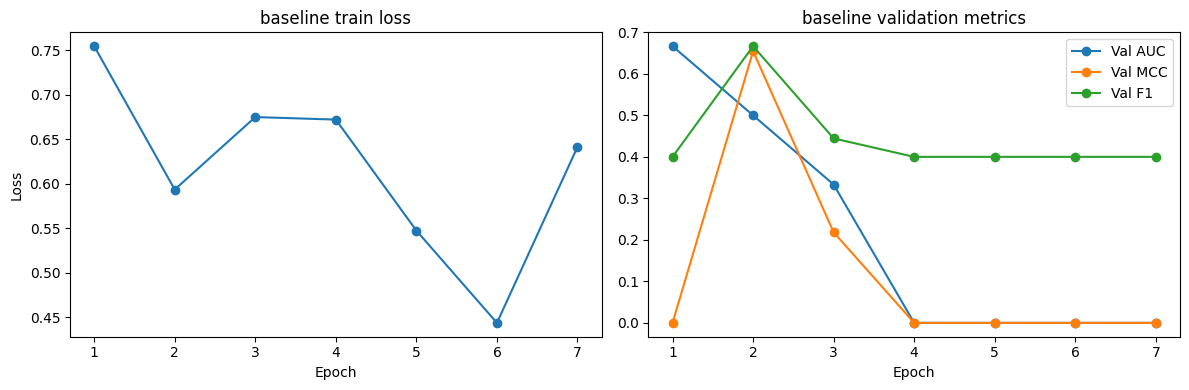

In [9]:
# ==========================================
# 9) Load best baseline checkpoint and test
# ==========================================
baseline_model.load_state_dict(baseline_best_state)
baseline_model.eval()

baseline_test_y, baseline_test_probs = baseline_predict_probs(baseline_model, baseline_test_loader)
baseline_test_metrics, baseline_test_pred = baseline_metrics_from_probs(
    baseline_test_y, baseline_test_probs, threshold=baseline_best_threshold
)

baseline_cm = confusion_matrix(baseline_test_y, baseline_test_pred, labels=[0, 1])

print("baseline test metrics:")
for k, v in baseline_test_metrics.items():
    print(f" - {k}: {v:.4f}")

print("\nConfusion matrix [[TN, FP], [FN, TP]]:")
print(baseline_cm)

baseline_results_df = pd.DataFrame([{
    "Model": "Baseline - CrossTransformer-style",
    "Accuracy": baseline_test_metrics["accuracy"],
    "Sensitivity": baseline_test_metrics["sensitivity"],
    "Specificity": baseline_test_metrics["specificity"],
    "F1": baseline_test_metrics["f1"],
    "MCC": baseline_test_metrics["mcc"],
    "AUC": baseline_test_metrics["auc"],
    "Threshold": baseline_best_threshold,
    "Best Epoch": baseline_best_epoch,
}])
display(baseline_results_df)

baseline_report = classification_report(
    baseline_test_y,
    baseline_test_pred,
    target_names=["negative", "positive"],
    zero_division=0,
    output_dict=False,
)
print("\nClassification report:")
print(baseline_report)

baseline_metrics_for_report = {
    "accuracy": float(baseline_test_metrics["accuracy"]),
    "sensitivity": float(baseline_test_metrics["sensitivity"]),
    "specificity": float(baseline_test_metrics["specificity"]),
    "f1": float(baseline_test_metrics["f1"]),
    "mcc": float(baseline_test_metrics["mcc"]),
    "auc": float(baseline_test_metrics["auc"]),
    "threshold": float(baseline_best_threshold),
    "best_epoch": int(baseline_best_epoch),
}
with open("baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics_for_report, f, indent=2)

print("\nSaved:")
print(" -", BASELINE_MODEL_PATH.resolve())
print(" -", Path("baseline_metrics.json").resolve())

# lightweight curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(baseline_history_df["epoch"], baseline_history_df["train_loss"], marker="o")
axes[0].set_title("baseline train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(baseline_history_df["epoch"], baseline_history_df["auc"], marker="o", label="Val AUC")
axes[1].plot(baseline_history_df["epoch"], baseline_history_df["mcc"], marker="o", label="Val MCC")
axes[1].plot(baseline_history_df["epoch"], baseline_history_df["f1"], marker="o", label="Val F1")
axes[1].set_title("baseline validation metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

## Our actual model now

In [10]:

# =========================
# 1) Imports and config
# =========================
import os
import gc
import math
import random
import warnings
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_FALLBACK_ROOTS = [Path("./"), Path("../input")]

TARGET_COLUMN = "Amyloid_status"
POSITIVE_LABEL = "positive"
NEGATIVE_LABEL = "negative"

# IMPORTANT:
# Use the best available PET instead of requiring AV45.
# Requiring AV45 in ds006148 was the main reason PET was silently dropped.
PREFER_TRACER = "ANY_BEST_AVAILABLE"

# Keep the architecture the same, but feed it data that matches its design:
# MRI is the anchor; PET is optional and used whenever available.
KEEP_ONLY_ROWS_WITH_MRI = True
CHOOSE_ONE_SESSION_PER_SUBJECT = True
COMPARE_ON_PAIRED_ANY_PET = True

IMG_SIZE = (96, 96, 96)
BATCH_SIZE = 2
NUM_WORKERS = 0
EPOCHS = 25
LR = 8e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 8
GRAD_CLIP_NORM = 3.0
ACCUM_STEPS = 2

TOKEN_DIM = 96
NHEAD = 4
FUSION_DEPTH = 1
DROP_MODALITY_PROB = 0.20

LAMBDA_DROP = 0.35
LAMBDA_CONS = 0.10
CONSISTENCY_T = 2.0

TEST_SIZE = 0.15
VAL_SIZE_WITHIN_TRAINVAL = 0.17647058823529413

MIN_TRAIN_POS = 5
MIN_VAL_POS = 2
MIN_TEST_POS = 2
MAX_SPLIT_TRIES = 250

RUN_TRAINING = True
SAVE_DIR = Path("./missing_modality")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

THRESH_GRID = np.linspace(0.05, 0.95, 37)

BASELINE_METRICS_PATH = Path("./baseline_metrics.json")
if BASELINE_METRICS_PATH.exists():
    with open(BASELINE_METRICS_PATH, "r", encoding="utf-8") as f:
        BASELINE_METRICS = json.load(f)
    print("Loaded corrected baseline metrics from", BASELINE_METRICS_PATH)
else:
    BASELINE_METRICS = {}
    print("baseline_metrics.json not found yet.")
print("Baseline metrics used for comparison:", BASELINE_METRICS)


DEVICE: cuda
Loaded corrected baseline metrics from baseline_metrics.json
Baseline metrics used for comparison: {'accuracy': 0.625, 'sensitivity': 0.0, 'specificity': 0.8333333319444445, 'f1': 0.0, 'mcc': -0.2182178902359924, 'auc': 0.6666666666666667, 'threshold': 0.675, 'best_epoch': 2}


In [11]:

# ======================================
# 2) Discover Kaggle dataset roots/files
# ======================================
def find_matching_dirs(root: Path, pattern_substrings):
    hits = []
    if not root.exists():
        return hits
    for p in root.rglob("*"):
        if p.is_dir():
            s = str(p).lower()
            if all(tok in s for tok in pattern_substrings):
                hits.append(p)
    return sorted(set(hits))

def find_matching_files(root: Path, filename_regex):
    hits = []
    if not root.exists():
        return hits
    prog = re.compile(filename_regex, flags=re.IGNORECASE)
    for p in root.rglob("*"):
        if p.is_file() and prog.search(p.name):
            hits.append(p)
    return sorted(set(hits))

DATASET_ROOTS = []
if KAGGLE_INPUT_ROOT.exists():
    for batch_id in [1, 2, 3, 4]:
        ds_roots = find_matching_dirs(KAGGLE_INPUT_ROOT, [f"ds006148_dataset_batch_{batch_id}", "ds006148_data"])
        DATASET_ROOTS.extend(ds_roots)

if len(DATASET_ROOTS) == 0:
    for fallback in LOCAL_FALLBACK_ROOTS:
        DATASET_ROOTS.extend(find_matching_dirs(fallback, ["ds006148_data"]))

DATASET_ROOTS = sorted(set(DATASET_ROOTS))
print("Found dataset roots:")
for p in DATASET_ROOTS:
    print(" -", p)

QNLD_FILES = []
PARTICIPANTS_FILES = []
for root in [KAGGLE_INPUT_ROOT] + LOCAL_FALLBACK_ROOTS:
    QNLD_FILES.extend(find_matching_files(root, r"QNLD.*logfile.*\.csv$"))
    PARTICIPANTS_FILES.extend(find_matching_files(root, r"participants\.tsv$"))

QNLD_FILES = sorted(set(QNLD_FILES))
PARTICIPANTS_FILES = sorted(set(PARTICIPANTS_FILES))

print("\nFound QNLD metadata file(s):")
for p in QNLD_FILES:
    print(" -", p)

print("\nFound participants.tsv file(s):")
for p in PARTICIPANTS_FILES:
    print(" -", p)

if len(DATASET_ROOTS) == 0:
    raise FileNotFoundError("Could not find ds006148_data roots under the Kaggle input directory.")
if len(QNLD_FILES) == 0 and len(PARTICIPANTS_FILES) == 0:
    raise FileNotFoundError("Could not find either QNLD logfile CSV or participants.tsv.")


Found dataset roots:
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00005
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00005/ses-S001
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00005/ses-S001/anat
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00005/ses-S001/pet
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00011
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds006148_dataset_batch_1/ds006148_data/sub-C00011/ses-S001
 - /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/ds0

In [12]:

# ==========================
# 3) Load labels / metadata
# ==========================
def normalize_subject_token(x):
    s = str(x).strip().lower()
    s = s.replace("participant_", "").replace("participant-", "")
    s = s.replace("subject_", "").replace("subject-", "")
    s = s.replace("sub-", "")
    s = re.sub(r"[^a-z0-9]", "", s)
    return s

if len(QNLD_FILES) > 0:
    clinical = pd.read_csv(QNLD_FILES[0])
    source_name = str(QNLD_FILES[0])
else:
    clinical = pd.read_csv(PARTICIPANTS_FILES[0], sep="\t")
    source_name = str(PARTICIPANTS_FILES[0])

print("Metadata source:", source_name)
print("Shape:", clinical.shape)
print("First 30 columns:", clinical.columns.tolist()[:30])

preferred_id_cols = ["ID", "participant_id", "subject_id", "Subject", "subject", "participant"]
id_col = next((c for c in preferred_id_cols if c in clinical.columns), None)
if id_col is None:
    raise KeyError(f"Could not find a usable subject ID column in metadata. Columns were: {clinical.columns.tolist()[:50]}")
if TARGET_COLUMN not in clinical.columns:
    raise KeyError(f"Target column '{TARGET_COLUMN}' not found in metadata. Available columns include: {clinical.columns.tolist()[:50]}")

label_df = clinical[[id_col, TARGET_COLUMN]].copy()
label_df = label_df.dropna(subset=[TARGET_COLUMN]).copy()
label_df["_norm_subject"] = label_df[id_col].apply(normalize_subject_token)
label_df["_label_raw"] = label_df[TARGET_COLUMN].astype(str).str.strip().str.lower()
label_df = label_df[label_df["_label_raw"].isin([POSITIVE_LABEL, NEGATIVE_LABEL])].copy()
label_df["label"] = (label_df["_label_raw"] == POSITIVE_LABEL).astype(int)

label_conflicts = label_df.groupby("_norm_subject")["label"].nunique()
conflicting = label_conflicts[label_conflicts > 1]
if len(conflicting) > 0:
    print("Warning: some subjects had conflicting labels. Keeping first occurrence for:", conflicting.index.tolist()[:10])

label_df = label_df.drop_duplicates("_norm_subject").copy()

print("\nLabel counts:")
print(label_df["label"].value_counts().sort_index())
display(label_df.head())


Metadata source: /kaggle/input/datasets/mahadamir/openneuro-ds006148-dataset/QNLD_cognitive_scores_logfile.csv
Shape: (258, 92)
First 30 columns: ['ID', 'age_group', 'sex', 'Amyloid_status', 'Tau_Pattern', 'BensonFigure-FinalScore', 'BensonFigure-FinalScore-Delayed', 'PerceptualSpeed_CorrectResponses', 'PerceptualSpeed_OmissionErrors(correct numbers that were missed)', 'DKEFSdesign_Score', 'DKEFSdesign_SetLossErrors', 'DKEFSdesign_RepititionErrors', 'WTAR_score', 'MOCA_Score', 'CraftStory_UnitsRecalled_Verbatim', 'CraftStory_UnitsRecalled_Paraphrase', 'CraftStory_Delayed_VerbatimScoring', 'CraftStory_Delayed_ParaphraseScoring', 'AVLT_Recall 1', 'AVLT_Recall 2', 'AVLT_Recall 3', 'AVLT_Recall 4', 'AVLT_Recall 5', 'AVLT_Recall 6', 'AVLT_ListB_Recall', 'AVLT_Delayed_recalls', 'AVLTrecognition_FalsePositive', 'AVLTrecognition_TotalCorrect', 'NumberSpan_Forward_Correct', 'NumberSpan_Forward_LongestCorrectSeries:']

Label counts:
label
0    140
1     44
Name: count, dtype: int64


,ID,Amyloid_status,_norm_subject,_label_raw,label
0,C00143,Negative,c00143,negative,0
1,C00442,Negative,c00442,negative,0
2,C00508,Negative,c00508,negative,0
3,C00298,Positive,c00298,positive,1
4,C00158,Positive,c00158,positive,1


In [13]:

# ===========================================================
# 4) Scan ds006148 sessions and build the working dataframe
# ===========================================================
VOLUME_EXTS = (".nii", ".nii.gz", ".npy", ".npz")
PET_HINTS = ("pet", "trc-", "av45", "florbetapir", "fbb", "pib", "fdg", "mk6240")

def is_volume_file(path: Path):
    name = path.name.lower()
    return any(name.endswith(ext) for ext in VOLUME_EXTS)

def list_session_volume_files(session_root: Path):
    return sorted([p for p in session_root.rglob("*") if p.is_file() and is_volume_file(p)])

def tracer_from_path(path: Path):
    s = str(path).lower()
    m = re.search(r"trc-([a-z0-9]+)", s, flags=re.IGNORECASE)
    if m:
        token = m.group(1).upper()
        if token == "FLORBETAPIR":
            return "AV45"
        return token
    alias_map = {
        "FLORBETAPIR": "AV45",
        "AV45": "AV45",
        "FBB": "FBB",
        "PIB": "PIB",
        "FDG": "FDG",
        "MK6240": "MK6240",
    }
    up = s.upper()
    for k, v in alias_map.items():
        if k in up:
            return v
    return "UNKNOWN"

def score_mri(path: Path):
    s = str(path).lower()
    score = 0
    if re.search(r"(^|[_/-])t1w([_.-]|$)", s): score += 10
    if re.search(r"(^|[_/-])t1([_.-]|$)", s): score += 6
    if "mprage" in s or "spgr" in s: score += 5
    if "/anat/" in s: score += 3
    if "anat" in s or "mri" in s: score += 2
    if any(tok in s for tok in PET_HINTS): score -= 12
    return score

def score_pet(path: Path):
    s = str(path).lower()
    score = 0
    if re.search(r"(^|[_/-])pet([_.-]|$)", s): score += 10
    if "trc-" in s: score += 7
    if any(tok in s for tok in ("av45", "florbetapir", "fbb", "pib", "fdg", "mk6240")): score += 6
    if "/pet/" in s: score += 3
    if re.search(r"(^|[_/-])t1w([_.-]|$)", s) or re.search(r"(^|[_/-])t1([_.-]|$)", s): score -= 12
    if "anat" in s or "mprage" in s or "spgr" in s: score -= 10
    return score

def choose_mri_file(files):
    if len(files) == 0:
        return None
    ranked = sorted(((score_mri(p), p) for p in files), key=lambda x: x[0], reverse=True)
    return ranked[0][1] if ranked[0][0] > 0 else None

def choose_pet_file(files, prefer_tracer="ANY_BEST_AVAILABLE"):
    if len(files) == 0:
        return None, None
    prefer = str(prefer_tracer).strip().upper()
    ranked = sorted(((score_pet(p), p) for p in files), key=lambda x: x[0], reverse=True)
    pet_candidates = [p for sc, p in ranked if sc > 0]
    if len(pet_candidates) == 0:
        return None, None

    if prefer not in {"ANY", "ANY_BEST_AVAILABLE", "BEST_AVAILABLE", "NONE", ""}:
        for p in pet_candidates:
            tr = tracer_from_path(p)
            if tr == prefer:
                return p, tr

    p0 = pet_candidates[0]
    return p0, tracer_from_path(p0)

label_lookup = dict(zip(label_df["_norm_subject"], label_df["label"]))
requested_tracer = str(PREFER_TRACER).strip().upper()

records = []
for dataset_root in DATASET_ROOTS:
    subject_dirs = sorted([p for p in dataset_root.glob("sub-*") if p.is_dir()])
    for sub_dir in subject_dirs:
        session_dirs = sorted([p for p in sub_dir.glob("ses-*") if p.is_dir()])
        if len(session_dirs) == 0:
            session_dirs = [sub_dir]

        for ses_dir in session_dirs:
            norm_sub = normalize_subject_token(sub_dir.name)
            if norm_sub not in label_lookup:
                continue

            files = list_session_volume_files(ses_dir)
            mri_file = choose_mri_file(files)
            pet_file_any, pet_tracer_any = choose_pet_file(files, prefer_tracer=requested_tracer)

            has_mri = int(mri_file is not None)
            has_pet_any = int(pet_file_any is not None)

            records.append({
                "dataset_root": str(dataset_root),
                "subject_id": sub_dir.name,
                "session_id": ses_dir.name if ses_dir != sub_dir else "ses-S001",
                "_norm_subject": norm_sub,
                "label": int(label_lookup[norm_sub]),
                "mri_path": str(mri_file) if mri_file is not None else None,
                "pet_path_any": str(pet_file_any) if pet_file_any is not None else None,
                "pet_tracer_any": (pet_tracer_any if pet_tracer_any is not None else "UNKNOWN"),
                "has_mri": has_mri,
                "has_pet_any": has_pet_any,
            })

rows = pd.DataFrame(records)
if len(rows) == 0:
    raise RuntimeError("No usable subject/session rows were found.")

rows = rows.sort_values(["subject_id", "session_id", "dataset_root"]).drop_duplicates(
    subset=["subject_id", "session_id"], keep="first"
).reset_index(drop=True)

rows["pet_tracer_any"] = rows["pet_tracer_any"].fillna("UNKNOWN").astype(str).str.upper()
rows["pet_path"] = rows["pet_path_any"]
rows["has_pet"] = rows["has_pet_any"]
rows["_prefer_av45"] = (rows["pet_tracer_any"] == "AV45").astype(int)

# Keep one representative session per subject to reduce repeated near-duplicates.
# Preference order:
# 1) MRI present (required)
# 2) PET present
# 3) AV45 if available
# 4) earliest session string for determinism
if CHOOSE_ONE_SESSION_PER_SUBJECT:
    rows = rows.sort_values(
        by=["subject_id", "has_mri", "has_pet", "_prefer_av45", "session_id"],
        ascending=[True, False, False, False, True],
    ).copy()
    rows = rows.groupby("subject_id", as_index=False).first()

if KEEP_ONLY_ROWS_WITH_MRI:
    work_df = rows[rows["has_mri"] == 1].copy()
else:
    work_df = rows[(rows["has_mri"] == 1) | (rows["has_pet"] == 1)].copy()

work_df = work_df.reset_index(drop=True)

if len(work_df) == 0:
    raise RuntimeError("work_df is empty after filtering.")

print("Final working dataframe shape:", work_df.shape)
print("\nLabel counts:")
print(work_df["label"].value_counts().sort_index())
print("\nModality availability counts:")
display(work_df[["has_mri", "has_pet"]].value_counts().rename("count").reset_index())
print("\nTracer counts among kept rows:")
print(work_df["pet_tracer_any"].value_counts(dropna=False))
display(work_df.head())

if int(work_df["has_pet"].sum()) == 0:
    raise RuntimeError(
        "All PET rows were filtered out. This should not happen in the corrected notebook."
    )


Final working dataframe shape: (52, 13)

Label counts:
label
0    41
1    11
Name: count, dtype: int64

Modality availability counts:


,has_mri,has_pet,count
0,1,1,52



Tracer counts among kept rows:
pet_tracer_any
FDG       49
MK6240     3
Name: count, dtype: int64


,subject_id,dataset_root,session_id,_norm_subject,label,mri_path,pet_path_any,pet_tracer_any,has_mri,has_pet_any,pet_path,has_pet,_prefer_av45
0,sub-C00007,/kaggle/input/datasets/mahadamir/openneuro-ds0...,ses-S001,c00007,0,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,1,0
1,sub-C00011,/kaggle/input/datasets/mahadamir/openneuro-ds0...,ses-S001,c00011,0,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,1,0
2,sub-C00012,/kaggle/input/datasets/mahadamir/openneuro-ds0...,ses-S001,c00012,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,1,0
3,sub-C00013,/kaggle/input/datasets/mahadamir/openneuro-ds0...,ses-S001,c00013,0,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,1,0
4,sub-C00015,/kaggle/input/datasets/mahadamir/openneuro-ds0...,ses-S001,c00015,0,/kaggle/input/datasets/mahadamir/openneuro-ds0...,/kaggle/input/datasets/mahadamir/openneuro-ds0...,FDG,1,1,/kaggle/input/datasets/mahadamir/openneuro-ds0...,1,0


In [14]:

# ==============================================
# 5) Subject-wise leakage-safe splitting + fair
#    paired subset for baseline comparison
# ==============================================
subject_df = work_df[["subject_id", "label"]].drop_duplicates().copy()

def has_both_classes(df):
    return len(df) > 0 and df["label"].nunique() == 2

def split_is_good(train_df, val_df, test_df):
    if not has_both_classes(train_df):
        return False
    if not has_both_classes(val_df):
        return False
    if not has_both_classes(test_df):
        return False
    if int((train_df["label"] == 1).sum()) < MIN_TRAIN_POS:
        return False
    if int((val_df["label"] == 1).sum()) < MIN_VAL_POS:
        return False
    if int((test_df["label"] == 1).sum()) < MIN_TEST_POS:
        return False
    return True

found_split = False
split_seed_used = None

for split_try in range(MAX_SPLIT_TRIES):
    split_seed = SEED + split_try
    try:
        trainval_subs, test_subs = train_test_split(
            subject_df["subject_id"],
            test_size=TEST_SIZE,
            random_state=split_seed,
            stratify=subject_df["label"],
        )

        trainval_subject_df = subject_df[subject_df["subject_id"].isin(trainval_subs)].copy()

        train_subs, val_subs = train_test_split(
            trainval_subject_df["subject_id"],
            test_size=VAL_SIZE_WITHIN_TRAINVAL,
            random_state=split_seed,
            stratify=trainval_subject_df["label"],
        )
    except ValueError:
        continue

    train_df = work_df[work_df["subject_id"].isin(train_subs)].copy().reset_index(drop=True)
    val_df   = work_df[work_df["subject_id"].isin(val_subs)].copy().reset_index(drop=True)
    test_df  = work_df[work_df["subject_id"].isin(test_subs)].copy().reset_index(drop=True)

    if split_is_good(train_df, val_df, test_df):
        found_split = True
        split_seed_used = split_seed
        break

if not found_split:
    raise RuntimeError(
        "Could not find a robust subject split with enough positives in train/val/test. "
        "Try relaxing MIN_*_POS values."
    )

print("Actual-model split seed used:", split_seed_used)

def split_summary(df, name):
    return {
        "split": name,
        "n_rows": len(df),
        "n_subjects": df["subject_id"].nunique(),
        "positive": int((df["label"] == 1).sum()),
        "negative": int((df["label"] == 0).sum()),
        "with_mri": int((df["has_mri"] == 1).sum()),
        "with_pet": int((df["has_pet"] == 1).sum()),
        "paired_rows": int(((df["has_mri"] == 1) & (df["has_pet"] == 1)).sum()),
    }

summary_df = pd.DataFrame([
    split_summary(train_df, "train"),
    split_summary(val_df, "valid"),
    split_summary(test_df, "test"),
])
display(summary_df)

paired_val_df = val_df[(val_df["has_mri"] == 1) & (val_df["has_pet"] == 1)].copy().reset_index(drop=True)
paired_test_df = test_df[(test_df["has_mri"] == 1) & (test_df["has_pet"] == 1)].copy().reset_index(drop=True)

print("\nPaired validation subset shape:", paired_val_df.shape)
print("Paired test subset shape:", paired_test_df.shape)

display(pd.DataFrame([
    split_summary(paired_val_df, "paired_valid"),
    split_summary(paired_test_df, "paired_test"),
]))

assert set(train_df["subject_id"]).isdisjoint(set(val_df["subject_id"]))
assert set(train_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))
assert set(val_df["subject_id"]).isdisjoint(set(test_df["subject_id"]))
print("Subject leakage check passed.")

# Use the full validation split for checkpoint selection, because this is a missing-modality model.
selection_val_df = val_df.copy()

# Use the paired test subset only for baseline-vs-actual comparison when it is valid.
comparison_test_df = (
    paired_test_df.copy()
    if (COMPARE_ON_PAIRED_ANY_PET and has_both_classes(paired_test_df))
    else test_df.copy()
)

print("\nValidation subset used for checkpoint selection: valid")
print("Test subset used for baseline comparison:", "paired_test" if len(comparison_test_df) == len(paired_test_df) and len(paired_test_df) > 0 else "test")


Actual-model split seed used: 2026


,split,n_rows,n_subjects,positive,negative,with_mri,with_pet,paired_rows
0,train,36,36,7,29,36,36,36
1,valid,8,8,2,6,8,8,8
2,test,8,8,2,6,8,8,8



Paired validation subset shape: (8, 13)
Paired test subset shape: (8, 13)


,split,n_rows,n_subjects,positive,negative,with_mri,with_pet,paired_rows
0,paired_valid,8,8,2,6,8,8,8
1,paired_test,8,8,2,6,8,8,8


Subject leakage check passed.

Validation subset used for checkpoint selection: valid
Test subset used for baseline comparison: paired_test


In [15]:

# =====================================
# 6) Preprocessing and volume utilities
# =====================================
def load_nifti(path):
    img = nib.load(str(path))
    arr = img.get_fdata(dtype=np.float32)
    if arr.ndim == 4:
        arr = arr.mean(axis=-1)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr

def crop_to_nonzero(arr, margin=4):
    nz = np.argwhere(arr > 0)
    if nz.size == 0:
        return arr
    mins = np.maximum(nz.min(axis=0) - margin, 0)
    maxs = np.minimum(nz.max(axis=0) + margin + 1, np.array(arr.shape))
    return arr[mins[0]:maxs[0], mins[1]:maxs[1], mins[2]:maxs[2]]

def robust_intensity_normalize(arr, modality="mri"):
    arr = crop_to_nonzero(arr)
    valid = np.isfinite(arr)
    if valid.sum() == 0:
        return np.zeros_like(arr, dtype=np.float32)

    vals = arr[valid]
    if modality == "mri":
        p_low, p_high = np.percentile(vals, [0.5, 99.5])
        arr = np.clip(arr, p_low, p_high)
        arr = arr - arr.min()
        denom = arr.max() - arr.min()
        if denom > 1e-6:
            arr = arr / denom
    else:
        p_low, p_high = np.percentile(vals, [1.0, 99.0])
        arr = np.clip(arr, p_low, p_high)
        nonzero = arr[arr > 0]
        if len(nonzero) > 10:
            mu = nonzero.mean()
            sd = nonzero.std() + 1e-6
            arr = (arr - mu) / sd
            arr = np.clip(arr, -5, 5)
            arr = (arr + 5) / 10.0
        else:
            arr = arr - arr.min()
            denom = arr.max() - arr.min()
            if denom > 1e-6:
                arr = arr / denom
    return arr.astype(np.float32)

def resize_volume(arr, out_size=IMG_SIZE):
    x = torch.from_numpy(arr).float()[None, None]
    x = F.interpolate(x, size=out_size, mode="trilinear", align_corners=False)
    return x[0]

def preprocess_path(path, modality="mri"):
    arr = load_nifti(path)
    arr = robust_intensity_normalize(arr, modality=modality)
    x = resize_volume(arr, IMG_SIZE)
    return x

ZERO_VOLUME = torch.zeros((1, *IMG_SIZE), dtype=torch.float32)

def apply_pair_augmentation(mri_tensor, pet_tensor, do_aug=True):
    if not do_aug:
        return mri_tensor, pet_tensor
    for dim in [1, 2, 3]:
        if random.random() < 0.5:
            mri_tensor = torch.flip(mri_tensor, dims=[dim])
            pet_tensor = torch.flip(pet_tensor, dims=[dim])
    if random.random() < 0.3:
        scale = 0.9 + 0.2 * random.random()
        shift = (random.random() - 0.5) * 0.08
        mri_tensor = (mri_tensor * scale + shift).clamp(0, 1)
        pet_tensor = (pet_tensor * scale + shift).clamp(0, 1)
    return mri_tensor, pet_tensor


In [16]:

# ============================
# 7) Dataset and dataloaders
# ============================
class DS006148MissingModalityDataset(Dataset):
    def __init__(self, df: pd.DataFrame, training: bool = False):
        self.df = df.reset_index(drop=True).copy()
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        has_mri = int(row["has_mri"])
        has_pet = int(row["has_pet"])

        mri = preprocess_path(row["mri_path"], modality="mri") if has_mri == 1 else ZERO_VOLUME.clone()
        pet = preprocess_path(row["pet_path"], modality="pet") if has_pet == 1 else ZERO_VOLUME.clone()

        if self.training:
            mri, pet = apply_pair_augmentation(mri, pet, do_aug=True)

        return {
            "mri": mri,
            "pet": pet,
            "mask": torch.tensor([has_mri, has_pet], dtype=torch.float32),
            "label": torch.tensor(int(row["label"]), dtype=torch.long),
            "subject_id": row["subject_id"],
            "session_id": row["session_id"],
        }

train_ds = DS006148MissingModalityDataset(train_df, training=True)
val_ds   = DS006148MissingModalityDataset(val_df, training=False)
test_ds  = DS006148MissingModalityDataset(test_df, training=False)
selection_val_ds = DS006148MissingModalityDataset(selection_val_df, training=False)
comparison_test_ds = DS006148MissingModalityDataset(comparison_test_df, training=False)

train_label_counts = train_df["label"].value_counts().sort_index()
print("Improved-model train label counts:", train_label_counts.to_dict())

n0_loader = int(train_label_counts.get(0, 1))
n1_loader = int(train_label_counts.get(1, 1))
sample_weights = train_df["label"].map({
    0: 1.0 / max(n0_loader, 1),
    1: 1.0 / max(n1_loader, 1),
}).astype(float).values

train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g,
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
selection_val_loader = DataLoader(selection_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
comparison_test_loader = DataLoader(comparison_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

batch = next(iter(train_loader))
print("MRI batch shape:", batch["mri"].shape)
print("PET batch shape:", batch["pet"].shape)
print("Mask shape:", batch["mask"].shape)
print("Labels shape:", batch["label"].shape)
print("Improved-model train loader uses WeightedRandomSampler.")


Improved-model train label counts: {0: 29, 1: 7}
MRI batch shape: torch.Size([2, 1, 96, 96, 96])
PET batch shape: torch.Size([2, 1, 96, 96, 96])
Mask shape: torch.Size([2, 2])
Labels shape: torch.Size([2])
Improved-model train loader uses WeightedRandomSampler.


In [17]:
# ==========================================================
# 8) Model classes: encoders, tokenizer, attention pooling,
#    fusion, gating
# ==========================================================
class ConvBNAct3D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class ResidualBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = ConvBNAct3D(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.conv2 = nn.Sequential(
            nn.Conv3d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        self.skip = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv3d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm3d(out_ch),
            )
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        identity = self.skip(x)
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + identity
        out = self.act(out)
        return out

class Small3DEncoder(nn.Module):
    """Returns multi-scale features from stages 2, 3, and 4."""
    def __init__(self, in_ch=1, widths=(16, 32, 64, 128)):
        super().__init__()
        w1, w2, w3, w4 = widths
        self.stem = nn.Sequential(
            ConvBNAct3D(in_ch, w1, kernel_size=3, stride=2, padding=1),
            ConvBNAct3D(w1, w1, kernel_size=3, stride=1, padding=1),
        )
        self.stage1 = ResidualBlock3D(w1, w2, stride=2)
        self.stage2 = ResidualBlock3D(w2, w3, stride=2)
        self.stage3 = ResidualBlock3D(w3, w4, stride=2)
        self.stage4 = ResidualBlock3D(w4, w4, stride=2)
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        f2 = self.stage2(x)
        f3 = self.stage3(f2)
        f4 = self.stage4(f3)
        return f2, f3, f4

class MultiScaleSummary(nn.Module):
    """Summarizes stages 2/3/4 into one stable modality embedding."""
    def __init__(self, in_channels=(64, 128, 128), token_dim=96):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.proj = nn.Sequential(
            nn.Linear(sum(in_channels), token_dim),
            nn.LayerNorm(token_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )
    def forward(self, f2, f3, f4):
        pooled = [self.pool(f).flatten(1) for f in (f2, f3, f4)]
        return self.proj(torch.cat(pooled, dim=1))

class OptionalModalityGate(nn.Module):
    """Keeps MRI as the anchor and lets PET contribute only when present."""
    def __init__(self, token_dim):
        super().__init__()
        self.pet_gate = nn.Sequential(
            nn.Linear(token_dim * 2 + 2, token_dim),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(token_dim, 1),
        )
        self.mask_proj = nn.Sequential(
            nn.Linear(2, token_dim),
            nn.LayerNorm(token_dim),
        )
        self.out_norm = nn.LayerNorm(token_dim)
    def forward(self, mri_summary, pet_summary, mask):
        pet_present = mask[:, 1:2]
        gate_in = torch.cat([mri_summary, pet_summary, mask], dim=-1)
        pet_alpha = torch.sigmoid(self.pet_gate(gate_in)) * pet_present
        fused = mri_summary + 0.25 * pet_alpha * pet_summary + 0.10 * self.mask_proj(mask)
        fused = self.out_norm(fused)
        gate_weights = torch.cat([1.0 - pet_alpha, pet_alpha], dim=-1)
        return fused, gate_weights

class ImprovedMissingModalityNetV2(nn.Module):
    def __init__(self, token_dim=96, nhead=4, fusion_depth=1, num_classes=2):
        super().__init__()
        self.mri_encoder = Small3DEncoder(in_ch=1, widths=(16, 32, 64, 128))
        self.pet_encoder = Small3DEncoder(in_ch=1, widths=(16, 32, 64, 128))

        self.mri_summary_head = MultiScaleSummary(in_channels=(64, 128, 128), token_dim=token_dim)
        self.pet_summary_head = MultiScaleSummary(in_channels=(64, 128, 128), token_dim=token_dim)
        self.joint_summary_head = nn.Sequential(
            nn.Linear(token_dim * 2 + 2, token_dim),
            nn.LayerNorm(token_dim),
            nn.GELU(),
            nn.Dropout(0.10),
        )

        self.gate = OptionalModalityGate(token_dim)

        self.fused_proj = nn.Sequential(
            nn.Linear(token_dim * 3, token_dim),
            nn.LayerNorm(token_dim),
            nn.GELU(),
            nn.Dropout(0.15),
        )
        self.classifier = nn.Sequential(
            nn.Linear(token_dim, 128),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )
        self.mri_head = nn.Linear(token_dim, num_classes)
        self.pet_head = nn.Linear(token_dim, num_classes)

    def forward(self, mri, pet, mask):
        mri_f2, mri_f3, mri_f4 = self.mri_encoder(mri)
        pet_f2, pet_f3, pet_f4 = self.pet_encoder(pet)

        mri_summary = self.mri_summary_head(mri_f2, mri_f3, mri_f4)
        pet_summary_raw = self.pet_summary_head(pet_f2, pet_f3, pet_f4)
        pet_present = mask[:, 1:2]
        pet_summary = pet_summary_raw * pet_present

        joint_summary = self.joint_summary_head(torch.cat([mri_summary, pet_summary, mask], dim=-1))
        gated_fused, gate_weights = self.gate(mri_summary, pet_summary, mask)

        z_fused = self.fused_proj(torch.cat([mri_summary, joint_summary, gated_fused], dim=-1))

        fused_logits = self.classifier(z_fused)
        mri_logits = self.mri_head(mri_summary)
        pet_logits = self.pet_head(pet_summary)
        logits = fused_logits + 0.35 * mri_logits + 0.10 * pet_present * pet_logits

        batch_size = mri.shape[0]
        uniform_attn = torch.full(
            (batch_size, 1),
            1.0,
            dtype=z_fused.dtype,
            device=z_fused.device,
        )

        return {
            "logits": logits,
            "z_fused": z_fused,
            "cls_out": mri_summary,
            "mri_summary": mri_summary,
            "pet_summary": pet_summary,
            "joint_summary": joint_summary,
            "gate_weights": gate_weights,
            "mri_attn": uniform_attn,
            "pet_attn": uniform_attn,
            "joint_attn": uniform_attn,
        }

model = ImprovedMissingModalityNetV2(
    token_dim=TOKEN_DIM,
    nhead=NHEAD,
    fusion_depth=FUSION_DEPTH,
    num_classes=2,
).to(DEVICE)

with torch.no_grad():
    sample_mri = batch["mri"][:1].to(DEVICE)
    sample_pet = batch["pet"][:1].to(DEVICE)
    sample_mask = batch["mask"][:1].to(DEVICE)
    out = model(sample_mri, sample_pet, sample_mask)
    print("logits:", out["logits"].shape)
    print("z_fused:", out["z_fused"].shape)
    print("gate weights:", out["gate_weights"])


logits: torch.Size([1, 2])
z_fused: torch.Size([1, 96])
gate weights: tensor([[0.5132, 0.4868]], device='cuda:0')


In [18]:

# ====================================
# 9) Losses, metrics, helper functions
# ====================================
train_label_counts = train_df["label"].value_counts().sort_index()
n0 = int(train_label_counts.get(0, 1))
n1 = int(train_label_counts.get(1, 1))

class_weights = torch.tensor(
    [1.0 / max(n0, 1), 1.0 / max(n1, 1)],
    dtype=torch.float32,
    device=DEVICE,
)
class_weights = class_weights / class_weights.mean()

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.01,
)
VALID_THRESHOLD_GRID = THRESH_GRID

def compute_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return float(tn / (tn + fp + 1e-8))

def metrics_from_probs(y_true, probs, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)
    y_pred = (probs >= threshold).astype(int)

    metrics = {}
    metrics["pred_pos_rate"] = float(y_pred.mean())
    metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
    metrics["sensitivity"] = float(recall_score(y_true, y_pred, zero_division=0))
    metrics["specificity"] = float(compute_specificity(y_true, y_pred))
    metrics["balanced_accuracy"] = float(0.5 * (metrics["sensitivity"] + metrics["specificity"]))
    metrics["f1"] = float(f1_score(y_true, y_pred, zero_division=0))
    metrics["mcc"] = float(matthews_corrcoef(y_true, y_pred))
    try:
        metrics["auc"] = float(roc_auc_score(y_true, probs))
    except Exception:
        metrics["auc"] = float("nan")
    return metrics, y_pred

def metric_tuple(metrics_dict):
    noncollapse_flag = int(
        (metrics_dict["pred_pos_rate"] > 0.0)
        and (metrics_dict["pred_pos_rate"] < 1.0)
        and (metrics_dict["sensitivity"] > 0.0)
        and (metrics_dict["specificity"] > 0.0)
    )
    auc_term = metrics_dict["auc"] if np.isfinite(metrics_dict["auc"]) else -1e9
    return (
        noncollapse_flag,
        metrics_dict["mcc"],
        metrics_dict["balanced_accuracy"],
        metrics_dict["f1"],
        auc_term,
        metrics_dict["sensitivity"],
    )

def find_best_threshold(y_true, probs, thresholds=VALID_THRESHOLD_GRID):
    y_true = np.asarray(y_true).astype(int)
    probs = np.asarray(probs).astype(float)
    best_thr = 0.5
    best_tuple = (-1e9, -1e9, -1e9, -1e9, -1e9, -1e9)
    best_metrics = None
    for thr in thresholds:
        m, _ = metrics_from_probs(y_true, probs, threshold=float(thr))
        tup = metric_tuple(m)
        if tup > best_tuple:
            best_tuple = tup
            best_thr = float(thr)
            best_metrics = m
    return best_thr, best_metrics

def simulate_drop_mask(mask, drop_prob=DROP_MODALITY_PROB):
    drop_mask = mask.clone()
    both_present = (mask[:, 0] == 1) & (mask[:, 1] == 1)
    if both_present.any():
        idx = torch.where(both_present)[0]
        do_drop = torch.rand(len(idx), device=mask.device) < drop_prob
        idx = idx[do_drop]
        if len(idx) > 0:
            which = torch.randint(low=0, high=2, size=(len(idx),), device=mask.device)
            drop_mask[idx, which] = 0.0
    return drop_mask

def kl_consistency_loss(logits_full, logits_drop, temperature=CONSISTENCY_T):
    p_full = F.softmax(logits_full / temperature, dim=-1)
    log_p_drop = F.log_softmax(logits_drop / temperature, dim=-1)
    return F.kl_div(log_p_drop, p_full, reduction="batchmean") * (temperature ** 2)

def move_batch_to_device(batch):
    return {
        "mri": batch["mri"].to(DEVICE, non_blocking=True),
        "pet": batch["pet"].to(DEVICE, non_blocking=True),
        "mask": batch["mask"].to(DEVICE, non_blocking=True),
        "label": batch["label"].to(DEVICE, non_blocking=True),
        "subject_id": batch["subject_id"],
        "session_id": batch["session_id"],
    }


In [19]:

# ==================================================
# 10) Training and evaluation loop utilities
# ==================================================
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    all_probs = []
    all_labels = []

    amp_enabled = (scaler is not None) and scaler.is_enabled()
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(loader, desc="Train", leave=False)
    for step, batch in enumerate(pbar, start=1):
        batch = move_batch_to_device(batch)
        mri = batch["mri"]
        pet = batch["pet"]
        mask = batch["mask"]
        y = batch["label"]

        with autocast(enabled=amp_enabled):
            out_full = model(mri, pet, mask)
            logits_full = out_full["logits"]
            ce_full = criterion(logits_full, y)

            drop_mask = simulate_drop_mask(mask, drop_prob=DROP_MODALITY_PROB)
            out_drop = model(mri, pet, drop_mask)
            logits_drop = out_drop["logits"]

            dropped_rows = (drop_mask != mask).any(dim=1)
            if dropped_rows.any():
                ce_drop = criterion(logits_drop[dropped_rows], y[dropped_rows])
                kl_cons = kl_consistency_loss(logits_full[dropped_rows], logits_drop[dropped_rows])
            else:
                ce_drop = torch.tensor(0.0, device=DEVICE)
                kl_cons = torch.tensor(0.0, device=DEVICE)

            loss = ce_full + LAMBDA_DROP * ce_drop + LAMBDA_CONS * kl_cons
            loss_to_backprop = loss / ACCUM_STEPS

        if amp_enabled:
            scaler.scale(loss_to_backprop).backward()
        else:
            loss_to_backprop.backward()

        do_step = (step % ACCUM_STEPS == 0) or (step == len(loader))
        if do_step:
            if amp_enabled:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

            if amp_enabled:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * y.size(0)
        probs = torch.softmax(logits_full.detach(), dim=-1)[:, 1].cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.detach().cpu().numpy())

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "ce_full": f"{ce_full.item():.4f}",
            "ce_drop": f"{float(ce_drop):.4f}",
            "kl": f"{float(kl_cons):.4f}",
        })

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    metrics, _ = metrics_from_probs(all_labels, all_probs, threshold=0.5)
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss, metrics

@torch.no_grad()
def collect_eval_outputs(model, loader, force_mask=None):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_labels = []
    all_subjects = []
    all_sessions = []

    for batch in tqdm(loader, desc="Eval", leave=False):
        batch = move_batch_to_device(batch)
        mri = batch["mri"]
        pet = batch["pet"]
        mask = batch["mask"]
        y = batch["label"]

        if force_mask is not None:
            force_mask_tensor = torch.tensor(force_mask, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            eval_mask = force_mask_tensor.repeat(mask.size(0), 1)
        else:
            eval_mask = mask

        out = model(mri, pet, eval_mask)
        logits = out["logits"]
        loss = criterion(logits, y)
        running_loss += loss.item() * y.size(0)

        probs = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y.detach().cpu().numpy())
        all_subjects.extend(batch["subject_id"])
        all_sessions.extend(batch["session_id"])

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    epoch_loss = running_loss / len(loader.dataset)

    eval_df = pd.DataFrame({
        "subject_id": all_subjects,
        "session_id": all_sessions,
        "y_true": all_labels.astype(int),
        "prob_pos": all_probs.astype(float),
    })
    return epoch_loss, eval_df

def evaluate_with_threshold(model, loader, threshold=0.5, force_mask=None):
    eval_loss, eval_df = collect_eval_outputs(model, loader, force_mask=force_mask)
    metrics, y_pred = metrics_from_probs(eval_df["y_true"].values, eval_df["prob_pos"].values, threshold=threshold)
    eval_df = eval_df.copy()
    eval_df["y_pred"] = y_pred.astype(int)
    return eval_loss, metrics, eval_df

def pretty_metrics(tag, loss, metrics, threshold):
    print(
        f"{tag:>8s} | "
        f"loss={loss:.4f} | "
        f"auc={metrics['auc']:.4f} | "
        f"mcc={metrics['mcc']:.4f} | "
        f"bacc={metrics['balanced_accuracy']:.4f} | "
        f"f1={metrics['f1']:.4f} | "
        f"sens={metrics['sensitivity']:.4f} | "
        f"spec={metrics['specificity']:.4f} | "
        f"posrate={metrics['pred_pos_rate']:.4f} | "
        f"thr={threshold:.2f}"
    )


In [20]:

# ==========================================
# 11) Optimizer, scheduler, scaler
# ==========================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)
scaler = GradScaler(enabled=False)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"GradScaler enabled: {scaler.is_enabled()}")
print(f"Total params: {n_params/1e6:.2f}M | Trainable: {n_trainable/1e6:.2f}M")
print("Class weights:", class_weights.detach().cpu().numpy())
print("Gradient accumulation steps:", ACCUM_STEPS)


GradScaler enabled: False
Total params: 3.73M | Trainable: 3.73M
Class weights: [0.38888887 1.611111  ]
Gradient accumulation steps: 2


In [21]:

# ==========================================
# 12) Train with early stopping on validation
#     MCC and threshold tuning on the validation set
# ==========================================
best_epoch = -1
best_threshold = 0.5
best_path = SAVE_DIR / "best_model.pt"
best_score_tuple = (-1e9, -1e9, -1e9, -1e9, -1e9, -1e9)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_auc": [],
    "val_auc": [],
    "train_f1": [],
    "val_f1": [],
    "train_mcc": [],
    "val_mcc": [],
    "train_bacc": [],
    "val_bacc": [],
    "val_threshold": [],
}

if RUN_TRAINING:
    no_improve = 0
    for epoch in range(1, EPOCHS + 1):
        print(f"\nEpoch {epoch}/{EPOCHS}")
        train_loss, train_metrics = train_one_epoch(model, train_loader, optimizer, scaler)

        val_loss_raw, val_eval_df_raw = collect_eval_outputs(model, selection_val_loader)
        val_thr, val_metrics = find_best_threshold(
            val_eval_df_raw["y_true"].values,
            val_eval_df_raw["prob_pos"].values,
            thresholds=VALID_THRESHOLD_GRID
        )
        val_score_tuple = metric_tuple(val_metrics)

        pretty_metrics("train", train_loss, train_metrics, threshold=0.50)
        pretty_metrics("valid", val_loss_raw, val_metrics, threshold=val_thr)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss_raw)
        history["train_auc"].append(train_metrics["auc"])
        history["val_auc"].append(val_metrics["auc"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])
        history["train_mcc"].append(train_metrics["mcc"])
        history["val_mcc"].append(val_metrics["mcc"])
        history["train_bacc"].append(train_metrics["balanced_accuracy"])
        history["val_bacc"].append(val_metrics["balanced_accuracy"])
        history["val_threshold"].append(val_thr)

        scheduler.step(val_metrics["mcc"] + 0.25 * val_metrics["balanced_accuracy"])

        if val_score_tuple > best_score_tuple:
            best_score_tuple = val_score_tuple
            best_epoch = epoch
            best_threshold = val_thr
            no_improve = 0
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_score_tuple": best_score_tuple,
                "best_threshold": best_threshold,
                "val_metrics": val_metrics,
                "config": {
                    "IMG_SIZE": IMG_SIZE,
                    "TOKEN_DIM": TOKEN_DIM,
                    "NHEAD": NHEAD,
                    "FUSION_DEPTH": FUSION_DEPTH,
                    "PREFER_TRACER": PREFER_TRACER,
                    "KEEP_ONLY_ROWS_WITH_MRI": KEEP_ONLY_ROWS_WITH_MRI,
                    "CHOOSE_ONE_SESSION_PER_SUBJECT": CHOOSE_ONE_SESSION_PER_SUBJECT,
                }
            }, best_path)
            print(f"Saved best checkpoint to: {best_path}")
        else:
            no_improve += 1
            print(f"No improvement for {no_improve} epoch(s).")

        if no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

    print(f"Best validation tuple: {best_score_tuple}")
    print(f"Best validation epoch: {best_epoch}")
    print(f"Best validation threshold: {best_threshold:.2f}")
else:
    print("RUN_TRAINING=False, skipping training loop.")



Epoch 1/25


Train:   0%|          | 0/18 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

   train | loss=0.7656 | auc=0.5926 | mcc=0.1925 | bacc=0.5833 | f1=0.6667 | sens=0.8333 | spec=0.3333 | posrate=0.7500 | thr=0.50
   valid | loss=0.7252 | auc=0.5000 | mcc=-0.3333 | bacc=0.3333 | f1=0.2500 | sens=0.5000 | spec=0.1667 | posrate=0.7500 | thr=0.55
Saved best checkpoint to: missing_modality/best_model.pt

Epoch 2/25


Train:   0%|          | 0/18 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

   train | loss=0.5048 | auc=0.9079 | mcc=0.6625 | bacc=0.8095 | f1=0.8696 | sens=0.9524 | spec=0.6667 | posrate=0.6944 | thr=0.50
   valid | loss=0.7166 | auc=0.2500 | mcc=0.0000 | bacc=0.5000 | f1=0.3333 | sens=0.5000 | spec=0.5000 | posrate=0.5000 | thr=0.42
No improvement for 7 epoch(s).

Epoch 13/25


Train:   0%|          | 0/18 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

   train | loss=0.5157 | auc=0.9406 | mcc=0.6724 | bacc=0.8250 | f1=0.8205 | sens=1.0000 | spec=0.6500 | posrate=0.6389 | thr=0.50
   valid | loss=0.7545 | auc=0.2500 | mcc=0.0000 | bacc=0.5000 | f1=0.3333 | sens=0.5000 | spec=0.5000 | posrate=0.5000 | thr=0.50
No improvement for 8 epoch(s).
Early stopping triggered.
Best validation tuple: (1, 0.3333333333333333, 0.6666666659722222, 0.5, 0.5833333333333334, 0.5)
Best validation epoch: 5
Best validation threshold: 0.68


In [22]:

# =======================================================
# 13) Load best checkpoint and run fair test comparison
#     using the tuned validation threshold
# =======================================================
if not best_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found at {best_path}")

ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
best_threshold = float(ckpt.get("best_threshold", 0.5))
print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Using tuned threshold:", best_threshold)

test_loss, test_metrics, test_eval_df = evaluate_with_threshold(
    model,
    comparison_test_loader,
    threshold=best_threshold,
)

pretty_metrics("test", test_loss, test_metrics, threshold=best_threshold)

print("\nTest confusion matrix:")
cm = confusion_matrix(test_eval_df["y_true"], test_eval_df["y_pred"], labels=[0, 1])
print(cm)

test_eval_df.head()


Loaded best checkpoint from epoch: 5
Using tuned threshold: 0.675


Eval:   0%|          | 0/4 [00:00<?, ?it/s]

    test | loss=0.8035 | auc=0.5000 | mcc=0.1491 | bacc=0.5833 | f1=0.4000 | sens=0.5000 | spec=0.6667 | posrate=0.3750 | thr=0.68

Test confusion matrix:
[[4 2]
 [1 1]]


,subject_id,session_id,y_true,prob_pos,y_pred
0,sub-C00011,ses-S001,0,0.664383,0
1,sub-C00019,ses-S001,0,0.660037,0
2,sub-C00043,ses-S001,0,0.682062,1
3,sub-C00062,ses-S001,1,0.692157,1
4,sub-C00116,ses-S001,1,0.622210,0


In [23]:

# ============================================================
# 14) Missing-modality stress tests on the full test split
# ============================================================
natural_loss, natural_metrics, natural_eval_df = evaluate_with_threshold(
    model, test_loader, threshold=best_threshold
)
mri_only_loss, mri_only_metrics, _ = evaluate_with_threshold(
    model, test_loader, threshold=best_threshold, force_mask=[1, 0]
)
pet_only_loss, pet_only_metrics, _ = evaluate_with_threshold(
    model, test_loader, threshold=best_threshold, force_mask=[0, 1]
)

pretty_metrics("natural_test", natural_loss, natural_metrics, threshold=best_threshold)
pretty_metrics("MRI-only", mri_only_loss, mri_only_metrics, threshold=best_threshold)
pretty_metrics("PET-only", pet_only_loss, pet_only_metrics, threshold=best_threshold)

stress_test_summary = pd.DataFrame([
    {"setting": "Natural / available test inputs", **natural_metrics},
    {"setting": "Forced MRI-only", **mri_only_metrics},
    {"setting": "Forced PET-only", **pet_only_metrics},
])
display(stress_test_summary)


Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

Eval:   0%|          | 0/4 [00:00<?, ?it/s]

natural_test | loss=0.8035 | auc=0.5000 | mcc=0.1491 | bacc=0.5833 | f1=0.4000 | sens=0.5000 | spec=0.6667 | posrate=0.3750 | thr=0.68
MRI-only | loss=0.7517 | auc=0.5833 | mcc=0.0000 | bacc=0.5000 | f1=0.0000 | sens=0.0000 | spec=1.0000 | posrate=0.0000 | thr=0.68
PET-only | loss=0.7977 | auc=0.5000 | mcc=0.3333 | bacc=0.6667 | f1=0.5000 | sens=0.5000 | spec=0.8333 | posrate=0.2500 | thr=0.68


,setting,pred_pos_rate,accuracy,sensitivity,specificity,balanced_accuracy,f1,mcc,auc
0,Natural / available test inputs,0.375,0.625,0.5,0.666667,0.583333,0.4,0.149071,0.500000
1,Forced MRI-only,0.000,0.750,0.0,1.000000,0.500000,0.0,0.000000,0.583333
2,Forced PET-only,0.250,0.750,0.5,0.833333,0.666667,0.5,0.333333,0.500000


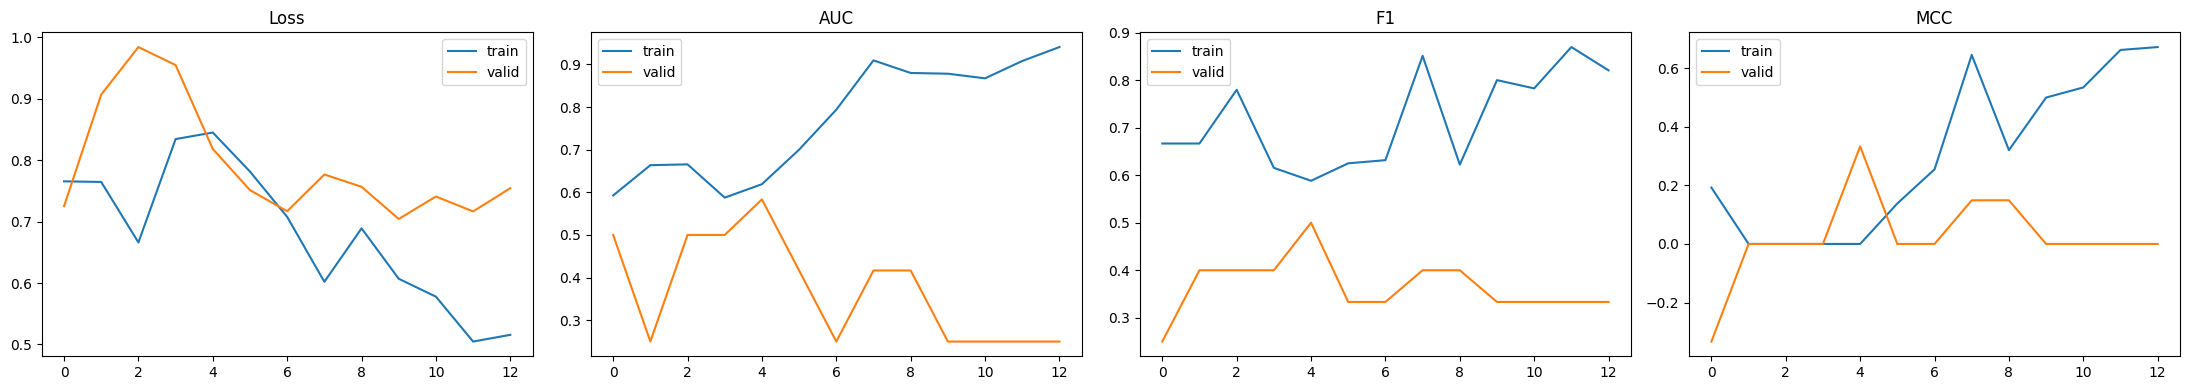

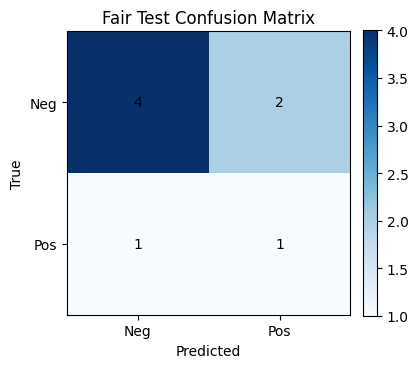

              precision    recall  f1-score   support

           0     0.8000    0.6667    0.7273         6
           1     0.3333    0.5000    0.4000         2

    accuracy                         0.6250         8
   macro avg     0.5667    0.5833    0.5636         8
weighted avg     0.6833    0.6250    0.6455         8



In [24]:

# ==========================================
# 15) Curves, confusion matrix, sample report
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="valid")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train")
axes[1].plot(history["val_auc"], label="valid")
axes[1].set_title("AUC")
axes[1].legend()

axes[2].plot(history["train_f1"], label="train")
axes[2].plot(history["val_f1"], label="valid")
axes[2].set_title("F1")
axes[2].legend()

axes[3].plot(history["train_mcc"], label="train")
axes[3].plot(history["val_mcc"], label="valid")
axes[3].set_title("MCC")
axes[3].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(test_eval_df["y_true"], test_eval_df["y_pred"], labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Neg", "Pos"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Neg", "Pos"])
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Fair Test Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

print(classification_report(test_eval_df["y_true"], test_eval_df["y_pred"], digits=4))


In [25]:

# ==========================================================
# 16) Generate a live baseline-vs-improved comparison table
# ==========================================================
from IPython.display import display, Markdown

if not BASELINE_METRICS:
    raise RuntimeError(
        "baseline_metrics.json was not found. Run the baseline section above first so the comparison table can be built."
    )

comparison_df = pd.DataFrame([
    {
        "Model": "Baseline - CrossTransformer_IT",
        "Accuracy": BASELINE_METRICS["accuracy"],
        "Sensitivity": BASELINE_METRICS["sensitivity"],
        "Specificity": BASELINE_METRICS["specificity"],
        "F1": BASELINE_METRICS["f1"],
        "MCC": BASELINE_METRICS["mcc"],
        "AUC": BASELINE_METRICS["auc"],
    },
    {
        "Model": "Improved Missing-Modality Fusion V2",
        "Accuracy": test_metrics["accuracy"],
        "Sensitivity": test_metrics["sensitivity"],
        "Specificity": test_metrics["specificity"],
        "F1": test_metrics["f1"],
        "MCC": test_metrics["mcc"],
        "AUC": test_metrics["auc"],
    }
])
display(comparison_df)

summary_md = f"""
## Baseline vs Improved Model

| Model | Accuracy | Sensitivity | Specificity | F1 | MCC | AUC |
|---|---:|---:|---:|---:|---:|---:|
| Baseline - CrossTransformer_IT | {BASELINE_METRICS['accuracy']:.4f} | {BASELINE_METRICS['sensitivity']:.4f} | {BASELINE_METRICS['specificity']:.4f} | {BASELINE_METRICS['f1']:.4f} | {BASELINE_METRICS['mcc']:.4f} | {BASELINE_METRICS['auc']:.4f} |
| Improved Missing-Modality Fusion V2 | {test_metrics['accuracy']:.4f} | {test_metrics['sensitivity']:.4f} | {test_metrics['specificity']:.4f} | {test_metrics['f1']:.4f} | {test_metrics['mcc']:.4f} | {test_metrics['auc']:.4f} |

### Interpretation
- If specificity stays near 1.0 but sensitivity/F1/MCC remain near 0, the model is still collapsing to the negative class.
- This corrected notebook directly addresses that failure mode with:
  - PET retention instead of AV45-only dropping
  - weighted sampling
  - class-weighted CE
  - threshold selection that avoids all-negative checkpoints
  - robust subject-wise splitting
  - MRI-anchored missing-modality training
"""
display(Markdown(summary_md))


,Model,Accuracy,Sensitivity,Specificity,F1,MCC,AUC
0,Baseline - CrossTransformer_IT,0.625,0.0,0.833333,0.0,-0.218218,0.666667
1,Improved Missing-Modality Fusion V2,0.625,0.5,0.666667,0.4,0.149071,0.500000



## Baseline vs Improved Model

| Model | Accuracy | Sensitivity | Specificity | F1 | MCC | AUC |
|---|---:|---:|---:|---:|---:|---:|
| Baseline - CrossTransformer_IT | 0.6250 | 0.0000 | 0.8333 | 0.0000 | -0.2182 | 0.6667 |
| Improved Missing-Modality Fusion V2 | 0.6250 | 0.5000 | 0.6667 | 0.4000 | 0.1491 | 0.5000 |

### Interpretation
- If specificity stays near 1.0 but sensitivity/F1/MCC remain near 0, the model is still collapsing to the negative class.
- This corrected notebook directly addresses that failure mode with:
  - PET retention instead of AV45-only dropping
  - weighted sampling
  - class-weighted CE
  - threshold selection that avoids all-negative checkpoints
  - robust subject-wise splitting
  - MRI-anchored missing-modality training
